In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import xarray as xr

# Path to your NetCDF file
file_path = r"/kaggle/input/black-carbon/2013_01_daily_12km_dustfix.nc"

# Load the dataset
ds = xr.open_dataset(file_path)

# Print dataset summary
print("✅ Dataset loaded successfully.")
print(ds)

# List all variables
print("\n✅ Variables in the dataset:")
print(list(ds.data_vars))

# Show metadata attributes
print("\n✅ Global attributes:")
print(ds.attrs)

# If you want to see a specific variable (e.g., 'dust')
# Replace 'dust' with the variable name you want to inspect
# For example, to look at 'dust' variable data:
# dust_data = ds['dust']
# print(dust_data)

# Example: display first few values of all variables
for var in ds.data_vars:
    print(f"\n✅ Data preview for variable '{var}':")
    print(ds[var].values)

# Close the dataset when done
ds.close()


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
file_path = "/kaggle/input/black-carbon/2013_01_daily_12km_dustfix.nc"
ds = xr.open_dataset(file_path)

# Extract black carbon (BC) and dust data
bc = ds["DEP_BC"].sum(dim="HOUR")
dust = sum([ds[f"DUST_{i}"].sum(dim="HOUR") for i in range(1, 6)])

# Total sums
total_bc = float(bc.sum().values)
total_dust = float(dust.sum().values)
dust_to_bc_ratio = (total_dust / total_bc) * 100

print(f"✅ Total Black Carbon: {total_bc:.2f}")
print(f"✅ Total Dust: {total_dust:.2f}")
print(f"✅ Dust-to-Black Carbon Ratio: {dust_to_bc_ratio:.2f}%")

# ========================
# 🟦 Visualizations
# ========================

# 1. Pie chart
plt.figure(figsize=(5, 5))
plt.pie([total_bc, total_dust], labels=["Black Carbon", "Dust"],
        autopct="%1.1f%%", colors=["#2E86AB", "#F5B041"], textprops={'fontsize': 12})
plt.title("Black Carbon vs Dust Proportion")
plt.tight_layout()
plt.show()

# 2. Time series plot (mean per hour)
bc_hourly = ds["DEP_BC"].mean(dim=["ROW", "COL"]).to_series()
dust_hourly = sum([ds[f"DUST_{i}"].mean(dim=["ROW", "COL"]).to_series() for i in range(1, 6)])

plt.figure(figsize=(12, 4))
plt.plot(bc_hourly, label="Black Carbon")
plt.plot(dust_hourly, label="Dust")
plt.title("Hourly Average Concentration")
plt.xlabel("Time Index")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Heatmaps (spatial plots)
def plot_heat(data_array, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(data_array, cmap="hot", origin="lower")
    plt.colorbar(label="Concentration")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_heat(bc.mean(dim="HOUR"), "Average Black Carbon Concentration")
plot_heat(dust.mean(dim="HOUR"), "Average Dust Concentration")

# 4. Bar Chart for Daily BC vs Dust
bc_daily = ds["DEP_BC"].mean(dim=["ROW", "COL"]).to_series()
dust_daily = sum([ds[f"DUST_{i}"].mean(dim=["ROW", "COL"]).to_series() for i in range(1, 6)])
df_daily = pd.DataFrame({"BC": bc_daily, "Dust": dust_daily})

df_daily.plot(kind="bar", figsize=(14, 4), title="Black Carbon vs Dust by Hour", colormap="tab10")
plt.xlabel("Hour Index")
plt.ylabel("Mean Concentration")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set file paths (you'll need to update this)
glacier_file = '/kaggle/input/database/database.csv'  # or .xlsx or .txt
bc_file = '/kaggle/input/black-carbon/2013_01_daily_12km_dustfix.nc'  # assuming NetCDF format from Zenodo

# Enhanced Glacier Mass Balance Data Loading
def load_glacier_data(filepath):
    """Load and preprocess glacier mass balance data with enhanced error handling"""
    try:
        # Try different file formats
        if filepath.endswith('.csv'):
            glacier_df = pd.read_csv(filepath)
        elif filepath.endswith('.xlsx'):
            glacier_df = pd.read_excel(filepath)
        elif filepath.endswith('.txt'):
            glacier_df = pd.read_csv(filepath, delimiter='\t')
        else:
            glacier_df = pd.read_csv(filepath)  # Default to CSV
            
        print("✓ Glacier Mass Balance Data Loaded Successfully")
        print(f"Shape: {glacier_df.shape}")
        print(f"Columns: {list(glacier_df.columns)}")
        print("\nFirst 5 rows:")
        print(glacier_df.head())
        print("\nData types:")
        print(glacier_df.dtypes)
        print("\nBasic statistics:")
        print(glacier_df.describe())
        
        # Check for missing values
        missing_vals = glacier_df.isnull().sum()
        if missing_vals.any():
            print(f"\nMissing values:\n{missing_vals[missing_vals > 0]}")
            
        return glacier_df
        
    except FileNotFoundError:
        print(f"❌ File not found: {filepath}")
        print("Please check the file path and ensure the file exists.")
        return None
    except Exception as e:
        print(f"❌ Error loading glacier data: {e}")
        return None

# Enhanced BC Deposition Data Loading
def load_bc_data(filepath):
    """Load and explore BC deposition NetCDF data"""
    try:
        bc_ds = xr.open_dataset(filepath)
        print("\n✓ BC Deposition Dataset Loaded Successfully")
        print(f"Dimensions: {dict(bc_ds.dims)}")
        print(f"Data variables: {list(bc_ds.data_vars)}")
        print(f"Coordinates: {list(bc_ds.coords)}")
        
        # Display dataset info
        print(f"\nDataset overview:")
        print(bc_ds)
        
        # Check for time range
        if 'time' in bc_ds.coords:
            time_range = pd.to_datetime(bc_ds.time.values)
            print(f"\nTime range: {time_range.min()} to {time_range.max()}")
            print(f"Number of time steps: {len(time_range)}")
            
        return bc_ds
        
    except FileNotFoundError:
        print(f"❌ File not found: {filepath}")
        print("Please check the file path and ensure the NetCDF file exists.")
        return None
    except Exception as e:
        print(f"❌ Error loading BC dataset: {e}")
        return None

# Enhanced visualization function
def visualize_data(glacier_df, bc_ds):
    """Create comprehensive visualizations for both datasets"""
    
    # Set up the plotting style
    plt.style.use('seaborn-v0_8')
    fig_size = (15, 10)
    
    if glacier_df is not None:
        # Try to identify relevant columns automatically
        possible_year_cols = ['Year', 'year', 'YEAR', 'Date', 'date']
        possible_balance_cols = ['Mass_Balance', 'mass_balance', 'Balance', 'balance', 
                               'Annual_Balance', 'MB', 'mb']
        
        year_col = None
        balance_col = None
        
        for col in possible_year_cols:
            if col in glacier_df.columns:
                year_col = col
                break
                
        for col in possible_balance_cols:
            if col in glacier_df.columns:
                balance_col = col
                break
        
        if year_col and balance_col:
            plt.figure(figsize=(12, 6))
            
            # Main time series plot
            plt.subplot(2, 2, 1)
            sns.lineplot(data=glacier_df, x=year_col, y=balance_col, 
                        marker='o', linewidth=2, markersize=6)
            plt.title('Glacier Mass Balance Over Time', fontsize=14, fontweight='bold')
            plt.xlabel('Year', fontsize=12)
            plt.ylabel('Mass Balance (m w.e.)', fontsize=12)
            plt.grid(True, alpha=0.3)
            
            # Add trend line
            if len(glacier_df) > 2:
                x_vals = glacier_df[year_col].values
                y_vals = glacier_df[balance_col].values
                # Remove any NaN values
                mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
                if mask.sum() > 2:
                    slope, intercept, r_value, p_value, std_err = stats.linregress(
                        x_vals[mask], y_vals[mask])
                    trend_line = slope * x_vals + intercept
                    plt.plot(x_vals, trend_line, 'r--', alpha=0.8, 
                            label=f'Trend (R²={r_value**2:.3f})')
                    plt.legend()
            
            # Distribution plot
            plt.subplot(2, 2, 2)
            sns.histplot(glacier_df[balance_col].dropna(), kde=True, bins=20)
            plt.title('Distribution of Mass Balance Values', fontsize=14)
            plt.xlabel('Mass Balance (m w.e.)', fontsize=12)
            
            # Box plot by decade (if enough data)
            if len(glacier_df) > 10:
                plt.subplot(2, 2, 3)
                glacier_df_copy = glacier_df.copy()
                glacier_df_copy['Decade'] = (glacier_df_copy[year_col] // 10) * 10
                sns.boxplot(data=glacier_df_copy, x='Decade', y=balance_col)
                plt.title('Mass Balance by Decade', fontsize=14)
                plt.xticks(rotation=45)
            
            plt.tight_layout()
            plt.show()
            
        else:
            print(f"⚠  Could not find standard year/balance columns in glacier data.")
            print(f"Available columns: {list(glacier_df.columns)}")
            print("Please specify the correct column names.")
    
    # BC deposition visualizations
    if bc_ds is not None:
        # Try to identify BC-related variables
        possible_bc_vars = []
        for var in bc_ds.data_vars:
            var_lower = str(var).lower()
            if any(term in var_lower for term in ['bc', 'black', 'carbon', 'soot']):
                possible_bc_vars.append(var)
        
        if not possible_bc_vars:
            possible_bc_vars = list(bc_ds.data_vars)[:3]  # Take first 3 variables
            
        print(f"\nAnalyzing BC variables: {possible_bc_vars}")
        
        for i, var_name in enumerate(possible_bc_vars[:2]):  # Limit to 2 variables
            try:
                var_data = bc_ds[var_name]
                
                plt.figure(figsize=(15, 5))
                
                # Spatial mean over time
                plt.subplot(1, 3, 1)
                if 'time' in var_data.dims:
                    spatial_dims = [d for d in var_data.dims if d != 'time']
                    if spatial_dims:
                        time_series = var_data.mean(dim=spatial_dims)
                        time_series.plot(marker='o', markersize=3)
                        plt.title(f'{var_name}: Spatial Mean Over Time')
                        plt.grid(True, alpha=0.3)
                
                # Temporal mean spatial plot
                plt.subplot(1, 3, 2)
                if 'time' in var_data.dims:
                    spatial_mean = var_data.mean(dim='time')
                else:
                    spatial_mean = var_data
                    
                im = spatial_mean.plot(cmap='inferno', add_colorbar=False)
                plt.title(f'{var_name}: Temporal Mean')
                plt.colorbar(im, label=f'{var_name} units')
                
                # Distribution histogram
                plt.subplot(1, 3, 3)
                values = var_data.values.flatten()
                values = values[~np.isnan(values)]  # Remove NaN values
                if len(values) > 0:
                    plt.hist(values, bins=50, alpha=0.7, edgecolor='black')
                    plt.title(f'{var_name}: Value Distribution')
                    plt.xlabel(f'{var_name} values')
                    plt.ylabel('Frequency')
                    plt.yscale('log')
                
                plt.tight_layout()
                plt.show()
                
            except Exception as e:
                print(f"⚠  Error plotting {var_name}: {e}")

# Analysis function for correlations
def analyze_correlation(glacier_df, bc_ds):
    """Analyze potential correlations between glacier mass balance and BC deposition"""
    
    if glacier_df is None or bc_ds is None:
        print("⚠  Both datasets needed for correlation analysis")
        return
    
    print("\n" + "="*50)
    print("CORRELATION ANALYSIS")
    print("="*50)
    
    # This is a placeholder for more sophisticated analysis
    # In practice, you'd need to:
    # 1. Spatially match glacier locations with BC grid points
    # 2. Temporally align the datasets
    # 3. Calculate correlations
    
    print("📊 For correlation analysis, you would need to:")
    print("1. Extract BC deposition values at glacier locations")
    print("2. Align temporal resolution (annual averages)")
    print("3. Calculate correlation coefficients")
    print("4. Test for statistical significance")

# Data quality checks
def quality_check(glacier_df, bc_ds):
    """Perform quality checks on both datasets"""
    
    print("\n" + "="*50)
    print("DATA QUALITY ASSESSMENT")
    print("="*50)
    
    if glacier_df is not None:
        print("\n🏔  GLACIER DATA QUALITY:")
        print(f"   • Total records: {len(glacier_df)}")
        print(f"   • Missing values: {glacier_df.isnull().sum().sum()}")
        print(f"   • Duplicate rows: {glacier_df.duplicated().sum()}")
        
        # Check for outliers in numeric columns
        numeric_cols = glacier_df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            Q1 = glacier_df[col].quantile(0.25)
            Q3 = glacier_df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((glacier_df[col] < (Q1 - 1.5 * IQR)) | 
                       (glacier_df[col] > (Q3 + 1.5 * IQR))).sum()
            print(f"   • {col} outliers: {outliers}")
    
    if bc_ds is not None:
        print("\n🌫  BC DATA QUALITY:")
        for var in list(bc_ds.data_vars)[:3]:  # Check first 3 variables
            data_array = bc_ds[var]
            total_vals = data_array.size
            nan_vals = np.isnan(data_array.values).sum()
            print(f"   • {var}: {total_vals} total values, {nan_vals} NaN ({nan_vals/total_vals*100:.1f}%)")

# Main execution function
def run_analysis():
    """Run the complete analysis pipeline"""
    
    print("🔍 GLACIER MASS BALANCE & BLACK CARBON ANALYSIS")
    print("=" * 60)
    
    # Load data
    glacier_df = load_glacier_data(glacier_file)
    bc_ds = load_bc_data(bc_file)
    
    # Quality checks
    quality_check(glacier_df, bc_ds)
    
    # Visualizations
    print(f"\n📊 Creating visualizations...")
    visualize_data(glacier_df, bc_ds)
    
    # Correlation analysis
    analyze_correlation(glacier_df, bc_ds)
    
    print(f"\n✅ Analysis complete!")
    
    return glacier_df, bc_ds

# Run the analysis
if __name__ == "__main__":
    glacier_data, bc_data = run_analysis()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

class RealisticBCAnalysis:
    def __init__(self, dataset_path=None):
        """
        Initialize Black Carbon Analysis with realistic data and proper validation
        """
        self.dataset_path = dataset_path
        self.data = None
        self.models = {}
        self.results = {}
        
        # Generate larger, more realistic dataset
        self.generate_realistic_data()
        
    def generate_realistic_data(self):
        """Generate larger, more realistic dataset with proper noise and complexity"""
        np.random.seed(50)
        
        # Generate more data points (simulate multiple days/locations)
        n_samples = 2000  # Increased sample size
        
        data_dict = {
            'sample_id': list(range(n_samples)),
            'DATETIME': [f'2013-01-{str((i//24) + 1).zfill(2)}T{str(i%24).zfill(2)}:00:00' 
                        for i in range(n_samples)]
        }
        
        # Generate more realistic data with complex relationships
        np.random.seed(42)
        
        # Base meteorological conditions
        temp_base = np.random.normal(280, 15, n_samples)  # More realistic temperature variation
        temp_daily = 5 * np.sin(np.arange(n_samples) * 2 * np.pi / 24)  # Daily cycle
        temperatures = temp_base + temp_daily + np.random.normal(0, 2, n_samples)
        
        # Precipitation (mostly zero with occasional events)
        rainfall = np.zeros(n_samples)
        rain_events = np.random.choice(n_samples, size=int(n_samples * 0.15), replace=False)
        rainfall[rain_events] = np.random.exponential(5, len(rain_events))
        
        # Snow (even less frequent)
        snow = np.zeros(n_samples)
        snow_events = np.random.choice(n_samples, size=int(n_samples * 0.05), replace=False)
        snow[snow_events] = np.random.exponential(2, len(snow_events))
        
        # Dust concentrations (independent sources)
        dust_1 = np.random.lognormal(1, 0.8, n_samples)
        dust_2 = np.random.lognormal(0.5, 0.6, n_samples)
        dust_3 = np.random.lognormal(0.2, 0.4, n_samples)
        
        # Organic carbon (somewhat related to BC but with noise)
        oc1_base = np.random.lognormal(2, 0.7, n_samples)
        oc2_base = np.random.lognormal(1.5, 0.6, n_samples)
        
        # Black carbon with realistic complexity
        # BC1: influenced by temperature, OC, some randomness
        bc1_temp_effect = -0.1 * (temperatures - 280)  # Slight temperature dependence
        bc1_oc_effect = 0.3 * oc1_base  # Moderate OC relationship
        bc1_random = np.random.lognormal(2.5, 0.6, n_samples)  # Base concentration
        bc1_noise = np.random.normal(0, 3, n_samples)  # Measurement noise
        bc1 = bc1_random + bc1_temp_effect + bc1_oc_effect + bc1_noise
        bc1 = np.maximum(bc1, 0.1)  # Ensure positive values
        
        # BC2: different source profile
        bc2_temp_effect = -0.05 * (temperatures - 280)
        bc2_oc_effect = 0.25 * oc2_base
        bc2_random = np.random.lognormal(2.2, 0.5, n_samples)
        bc2_noise = np.random.normal(0, 2.5, n_samples)
        bc2 = bc2_random + bc2_temp_effect + bc2_oc_effect + bc2_noise
        bc2 = np.maximum(bc2, 0.1)
        
        # PM2.5: composite of BC, OC, dust, and other sources
        pm25_bc_contribution = 0.4 * bc1 + 0.3 * bc2
        pm25_oc_contribution = 0.8 * oc1_base + 0.6 * oc2_base
        pm25_dust_contribution = 0.2 * dust_1 + 0.1 * dust_2
        pm25_other = np.random.lognormal(3, 0.8, n_samples)  # Other PM sources
        pm25_noise = np.random.normal(0, 5, n_samples)
        pm25 = pm25_bc_contribution + pm25_oc_contribution + pm25_dust_contribution + pm25_other + pm25_noise
        pm25 = np.maximum(pm25, 1)
        
        # Deposition processes (physically based)
        # Dry deposition: function of concentration and meteorology
        dd_bc1 = 0.02 * bc1 * (1 + 0.1 * np.maximum(temperatures - 280, 0)) + np.random.normal(0, 0.05, n_samples)
        dd_bc2 = 0.018 * bc2 * (1 + 0.08 * np.maximum(temperatures - 280, 0)) + np.random.normal(0, 0.04, n_samples)
        dd_bc1 = np.maximum(dd_bc1, 0)
        dd_bc2 = np.maximum(dd_bc2, 0)
        
        # Wet deposition: strongly dependent on precipitation
        wd_bc2 = 0.05 * bc2 * (1 + 2 * rainfall) + np.random.normal(0, 0.02, n_samples)
        wd_bc2 = np.maximum(wd_bc2, 0)
        
        # Total deposition
        dep_bc = dd_bc1 + dd_bc2 + wd_bc2 + np.random.normal(0, 0.1, n_samples)
        dep_bc = np.maximum(dep_bc, 0)
        
        # Coated/uncoated fractions
        dep_bc_coated = dep_bc * (0.6 + 0.2 * np.random.random(n_samples))
        dep_bc_uncoated = dep_bc - dep_bc_coated
        dep_bc_uncoated = np.maximum(dep_bc_uncoated, 0)
        
        # Store in dictionary
        data_dict.update({
            'BC1': bc1,
            'BC2': bc2,
            'DEP_BC': dep_bc,
            'DEP_BC_COATED': dep_bc_coated,
            'DEP_BC_UNCOATED': dep_bc_uncoated,
            'T2': temperatures,
            'RAINTOT': rainfall,
            'SNOW': snow,
            'PM2_5_DRY': pm25,
            'DD_BC1': dd_bc1,
            'DD_BC2': dd_bc2,
            'WD_BC2': wd_bc2,
            'OC1': oc1_base,
            'OC2': oc2_base,
            'DUST_1': dust_1,
            'DUST_2': dust_2,
            'DUST_3': dust_3
        })
        
        self.data = pd.DataFrame(data_dict)
        print("✅ Realistic dataset generated successfully!")
        print(f"Dataset shape: {self.data.shape}")
        print(f"Sample size increased to: {n_samples} (better for ML)")
        print(f"Variables: {len(self.data.columns)}")
        
    def train_models_with_validation(self, target='BC1'):
        """Train models with proper cross-validation to avoid overfitting"""
        
        # Prepare features and target
        feature_cols = ['T2', 'RAINTOT', 'SNOW', 'PM2_5_DRY', 'OC1', 'OC2', 
                       'DD_BC1', 'DD_BC2', 'WD_BC2', 'DUST_1', 'DUST_2']
        
        X = self.data[feature_cols].fillna(0)
        y = self.data[target].fillna(0)
        
        # Split data with larger test set
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Initialize models with regularization to prevent overfitting
        models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0),  # L2 regularization
            'Lasso Regression': Lasso(alpha=0.1),  # L1 regularization
            'Random Forest': RandomForestRegressor(
                n_estimators=50,  # Reduced to prevent overfitting
                max_depth=5,      # Limit tree depth
                min_samples_split=10,  # Require more samples to split
                min_samples_leaf=5,    # Require more samples in leaves
                random_state=42
            ),
            'Neural Network': MLPRegressor(
                hidden_layer_sizes=(20, 10),  # Smaller network
                max_iter=500,
                alpha=0.01,  # L2 regularization
                random_state=42
            )
        }
        
        # Cross-validation setup
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        self.results = {}
        
        print(f"Training models to predict {target} with cross-validation...")
        print("=" * 70)
        
        for name, model in models.items():
            print(f"Training {name}...")
            
            # Use scaled data for Neural Network and regularized models
            if name in ['Neural Network', 'Ridge Regression', 'Lasso Regression']:
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                
                # Cross-validation with scaled data
                cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                
                # Cross-validation with original data
                cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
            
            # Calculate metrics
            mse = mean_squared_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            
            # Cross-validation statistics
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            self.models[name] = model
            self.results[name] = {
                'mse': mse,
                'r2': r2,
                'mae': mae,
                'cv_r2_mean': cv_mean,
                'cv_r2_std': cv_std,
                'y_test': y_test,
                'y_pred': y_pred,
                'features': feature_cols
            }
            
            print(f"  Test R² Score: {r2:.4f}")
            print(f"  Cross-Val R² Mean: {cv_mean:.4f} (±{cv_std:.4f})")
            print(f"  Test MSE: {mse:.4f}")
            print(f"  Test MAE: {mae:.4f}")
            
            # Check for overfitting
            if r2 > cv_mean + 2*cv_std:
                print(f"  ⚠️  Possible overfitting detected!")
            else:
                print(f"  ✅ Model appears well-generalized")
            print()
        
        return self.results
    
    def plot_model_validation(self):
        """Plot model performance with validation metrics"""
        if not self.results:
            print("No model results available. Please train models first.")
            return
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Model Performance with Validation', fontsize=16, fontweight='bold')
        
        model_names = list(self.results.keys())
        
        # Test vs Cross-validation R² comparison
        test_r2 = [self.results[name]['r2'] for name in model_names]
        cv_r2_mean = [self.results[name]['cv_r2_mean'] for name in model_names]
        cv_r2_std = [self.results[name]['cv_r2_std'] for name in model_names]
        
        x_pos = np.arange(len(model_names))
        axes[0,0].bar(x_pos - 0.2, test_r2, 0.4, label='Test R²', alpha=0.8)
        axes[0,0].bar(x_pos + 0.2, cv_r2_mean, 0.4, yerr=cv_r2_std, 
                     label='CV R² (mean ± std)', alpha=0.8, capsize=5)
        axes[0,0].set_title('Test vs Cross-Validation R² Scores')
        axes[0,0].set_ylabel('R² Score')
        axes[0,0].set_xticks(x_pos)
        axes[0,0].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # MSE comparison
        mse_scores = [self.results[name]['mse'] for name in model_names]
        axes[0,1].bar(model_names, mse_scores, color='salmon', alpha=0.7)
        axes[0,1].set_title('Mean Squared Error')
        axes[0,1].set_ylabel('MSE')
        axes[0,1].tick_params(axis='x', rotation=45)
        for i, v in enumerate(mse_scores):
            axes[0,1].text(i, v + max(mse_scores)*0.01, f'{v:.2f}', ha='center', fontweight='bold')
        
        # MAE comparison
        mae_scores = [self.results[name]['mae'] for name in model_names]
        axes[0,2].bar(model_names, mae_scores, color='lightgreen', alpha=0.7)
        axes[0,2].set_title('Mean Absolute Error')
        axes[0,2].set_ylabel('MAE')
        axes[0,2].tick_params(axis='x', rotation=45)
        for i, v in enumerate(mae_scores):
            axes[0,2].text(i, v + max(mae_scores)*0.01, f'{v:.2f}', ha='center', fontweight='bold')
        
        # Predictions vs Actual for best CV model
        best_model = max(model_names, key=lambda x: self.results[x]['cv_r2_mean'])
        best_results = self.results[best_model]
        
        axes[1,0].scatter(best_results['y_test'], best_results['y_pred'], alpha=0.6, s=50)
        axes[1,0].plot([best_results['y_test'].min(), best_results['y_test'].max()], 
                       [best_results['y_test'].min(), best_results['y_test'].max()], 'r--', lw=2)
        axes[1,0].set_xlabel('Actual Values')
        axes[1,0].set_ylabel('Predicted Values')
        axes[1,0].set_title(f'Best Model: {best_model}')
        axes[1,0].grid(True, alpha=0.3)
        
        # Residuals plot
        residuals = best_results['y_test'] - best_results['y_pred']
        axes[1,1].scatter(best_results['y_pred'], residuals, alpha=0.6, s=50)
        axes[1,1].axhline(y=0, color='r', linestyle='--')
        axes[1,1].set_xlabel('Predicted Values')
        axes[1,1].set_ylabel('Residuals')
        axes[1,1].set_title(f'Residuals Plot - {best_model}')
        axes[1,1].grid(True, alpha=0.3)
        
        # Feature importance (for Random Forest)
        if 'Random Forest' in self.results:
            rf_model = self.models['Random Forest']
            feature_importance = pd.DataFrame({
                'feature': self.results['Random Forest']['features'],
                'importance': rf_model.feature_importances_
            }).sort_values('importance', ascending=True)
            
            axes[1,2].barh(feature_importance['feature'], feature_importance['importance'])
            axes[1,2].set_title('Feature Importance (Random Forest)')
            axes[1,2].set_xlabel('Importance')
        
        plt.tight_layout()
        plt.show()
    
    def check_overfitting_indicators(self):
        """Check for overfitting indicators"""
        print("🔍 OVERFITTING ANALYSIS")
        print("=" * 50)
        
        if not self.results:
            print("No model results available. Please train models first.")
            return
        
        for name, results in self.results.items():
            test_r2 = results['r2']
            cv_r2_mean = results['cv_r2_mean']
            cv_r2_std = results['cv_r2_std']
            
            print(f"\n📊 {name}:")
            print(f"   Test R²: {test_r2:.4f}")
            print(f"   CV R² Mean: {cv_r2_mean:.4f} (±{cv_r2_std:.4f})")
            
            # Check for overfitting signs
            gap = test_r2 - cv_r2_mean
            
            if gap > 2 * cv_r2_std:
                print(f"   🚨 HIGH overfitting risk (gap: {gap:.4f})")
            elif gap > cv_r2_std:
                print(f"   ⚠️  MODERATE overfitting risk (gap: {gap:.4f})")
            else:
                print(f"   ✅ GOOD generalization (gap: {gap:.4f})")
            
            # Check for unrealistic performance
            if test_r2 > 0.95:
                print(f"   🤔 Suspiciously high R² - check data leakage")
            
            # Check variance in CV scores
            if cv_r2_std > 0.1:
                print(f"   📊 High variance in CV scores - model unstable")
        
        print("\n💡 RECOMMENDATIONS:")
        print("   • R² > 0.95: Likely overfitted or data leakage")
        print("   • Test R² >> CV R²: Overfitting")
        print("   • High CV std: Use more data or simpler model")
        print("   • Good models: 0.6 < R² < 0.9 with stable CV")
    
    def plot_data_quality_checks(self):
        """Plot data quality and relationship checks"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Data Quality and Relationship Analysis', fontsize=16, fontweight='bold')
        
        # Target variable distribution
        axes[0,0].hist(self.data['BC1'], bins=20, alpha=0.7, edgecolor='black')
        axes[0,0].set_title('BC1 Distribution')
        axes[0,0].set_xlabel('BC1 Concentration')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].axvline(self.data['BC1'].mean(), color='red', linestyle='--', 
                         label=f'Mean: {self.data["BC1"].mean():.2f}')
        axes[0,0].legend()
        
        # Feature correlation heatmap (subset)
        important_vars = ['BC1', 'PM2_5_DRY', 'OC1', 'T2', 'RAINTOT']
        corr_subset = self.data[important_vars].corr()
        sns.heatmap(corr_subset, annot=True, cmap='coolwarm', center=0, ax=axes[0,1])
        axes[0,1].set_title('Key Variable Correlations')
        
        # Scatter plot matrix sample
        axes[1,0].scatter(self.data['PM2_5_DRY'], self.data['BC1'], alpha=0.6)
        axes[1,0].set_xlabel('PM2.5 Concentration')
        axes[1,0].set_ylabel('BC1 Concentration')
        axes[1,0].set_title('PM2.5 vs BC1 Relationship')
        axes[1,0].grid(True, alpha=0.3)
        
        # Check for outliers
        from scipy import stats
        z_scores = np.abs(stats.zscore(self.data['BC1']))
        outliers = z_scores > 3
        
        axes[1,1].scatter(range(len(self.data)), self.data['BC1'], 
                         c=['red' if x else 'blue' for x in outliers], alpha=0.6)
        axes[1,1].set_xlabel('Sample Index')
        axes[1,1].set_ylabel('BC1 Concentration')
        axes[1,1].set_title(f'Outlier Detection (Z-score > 3): {sum(outliers)} outliers')
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Usage with better practices
def main_realistic():
    """Main execution with realistic modeling practices"""
    print("🚀 Starting REALISTIC Black Carbon Analysis...")
    print("(With proper validation to avoid overfitting)")
    
    # Initialize analysis
    bc_analysis = RealisticBCAnalysis()
    
    # Check data quality first
    print("\n🔍 Checking data quality...")
    bc_analysis.plot_data_quality_checks()
    
    # Train models with proper validation
    print("\n🤖 Training models with cross-validation...")
    bc_analysis.train_models_with_validation('BC1')
    
    # Plot validation results
    print("\n📈 Analyzing model performance and validation...")
    bc_analysis.plot_model_validation()
    
    # Check for overfitting
    bc_analysis.check_overfitting_indicators()
    
    print("\n✅ Realistic analysis complete!")
    print("\n💡 Key improvements made:")
    print("   • Increased sample size (28 → 200)")
    print("   • Added model regularization")
    print("   • Used cross-validation")
    print("   • Added overfitting detection")
    print("   • More realistic data relationships")

# Run the improved analysis
if __name__ == "__main__":
    main_realistic()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

class BlackCarbonAnalysis:
    def __init__(self, dataset_path="/kaggle/input/database/database.csv"):
        """
        Initialize Black Carbon Analysis
        If dataset_path is None, generates synthetic data based on your dataset structure
        """
        self.dataset_path = dataset_path
        self.data = None
        self.models = {}
        self.results = {}
        
        # Generate synthetic data based on your dataset structure
        self.generate_synthetic_data()
        
    def generate_synthetic_data(self):
        """Generate synthetic data matching your xarray dataset structure"""
        np.random.seed(50)
        hours = 132800
        
        # Create synthetic data based on your dataset variables
        data_dict = {
            'HOUR': list(range(hours)),
            'DATETIME': [f'2013-01-{str((h//24) + 1).zfill(2)}T{str(h%24).zfill(2)}:00:00' 
                        for h in range(hours)]
        }
        
        # Generate BC concentrations with realistic patterns
        for h in range(hours):
            # Base concentrations with diurnal and random variations
            base_bc1 = 15 + 8 * np.sin(h * 0.5) + np.random.normal(0, 3)
            base_bc2 = 12 + 6 * np.cos(h * 0.3) + np.random.normal(0, 2.5)
            temp = 283 + 10 * np.sin(h * 0.2) + np.random.normal(0, 2)
            
            # Meteorological variables
            rain = max(0, np.random.exponential(2) if np.random.random() > 0.7 else 0)
            snow = max(0, np.random.exponential(1) if np.random.random() > 0.8 else 0)
            
            if h == 0:  # Initialize lists
                data_dict.update({
                    'BC1': [], 'BC2': [], 'DEP_BC': [], 'DEP_BC_COATED': [], 'DEP_BC_UNCOATED': [],
                    'T2': [], 'RAINTOT': [], 'SNOW': [], 'PM2_5_DRY': [],
                    'DD_BC1': [], 'DD_BC2': [], 'WD_BC2': [],
                    'OC1': [], 'OC2': [], 'DUST_1': [], 'DUST_2': [], 'DUST_3': []
                })
            
            # Append data for current hour
            data_dict['BC1'].append(max(0, base_bc1))
            data_dict['BC2'].append(max(0, base_bc2))
            data_dict['DEP_BC'].append(max(0, base_bc1 * 0.08 + np.random.normal(0, 0.02)))
            data_dict['DEP_BC_COATED'].append(max(0, base_bc1 * 0.05 + np.random.normal(0, 0.01)))
            data_dict['DEP_BC_UNCOATED'].append(max(0, base_bc1 * 0.03 + np.random.normal(0, 0.01)))
            data_dict['T2'].append(temp)
            data_dict['RAINTOT'].append(rain)
            data_dict['SNOW'].append(snow)
            data_dict['PM2_5_DRY'].append(max(0, base_bc1 * 2.5 + base_bc2 * 1.8 + np.random.normal(0, 5)))
            data_dict['DD_BC1'].append(max(0, base_bc1 * 0.04 + np.random.normal(0, 0.01)))
            data_dict['DD_BC2'].append(max(0, base_bc2 * 0.03 + np.random.normal(0, 0.008)))
            data_dict['WD_BC2'].append(max(0, base_bc2 * 0.02 * (1 + rain/10) + np.random.normal(0, 0.005)))
            data_dict['OC1'].append(max(0, base_bc1 * 0.8 + np.random.normal(0, 2)))
            data_dict['OC2'].append(max(0, base_bc2 * 0.7 + np.random.normal(0, 1.5)))
            data_dict['DUST_1'].append(max(0, np.random.exponential(3)))
            data_dict['DUST_2'].append(max(0, np.random.exponential(2)))
            data_dict['DUST_3'].append(max(0, np.random.exponential(1.5)))
        
        self.data = pd.DataFrame(data_dict)
        print("✅ Synthetic dataset generated successfully!")
        print(f"Dataset shape: {self.data.shape}")
        print(f"Variables: {list(self.data.columns)}")
        
    def load_real_dataset(self, file_path):
        """Load real xarray dataset if available"""
        try:
            ds = xr.open_dataset(file_path)
            # Convert to DataFrame and process
            df = ds.to_dataframe().reset_index()
            self.data = df
            print(f"✅ Real dataset loaded from {file_path}")
        except Exception as e:
            print(f"❌ Could not load real dataset: {e}")
            print("Using synthetic data instead.")
    
    def plot_time_series(self):
        """Plot time series of BC concentrations"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Black Carbon Time Series Analysis', fontsize=16, fontweight='bold')
        
        # BC1 and BC2
        axes[0,0].plot(self.data['HOUR'], self.data['BC1'], 'b-', linewidth=2, label='BC1', alpha=0.8)
        axes[0,0].plot(self.data['HOUR'], self.data['BC2'], 'g-', linewidth=2, label='BC2', alpha=0.8)
        axes[0,0].set_title('BC1 and BC2 Concentrations')
        axes[0,0].set_xlabel('Hour')
        axes[0,0].set_ylabel('Concentration (μg/m³)')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Deposition processes
        axes[0,1].plot(self.data['HOUR'], self.data['DEP_BC'], 'r-', linewidth=2, label='Total BC Deposition')
        axes[0,1].plot(self.data['HOUR'], self.data['DEP_BC_COATED'], 'm--', linewidth=2, label='Coated BC')
        axes[0,1].plot(self.data['HOUR'], self.data['DEP_BC_UNCOATED'], 'c--', linewidth=2, label='Uncoated BC')
        axes[0,1].set_title('BC Deposition Processes')
        axes[0,1].set_xlabel('Hour')
        axes[0,1].set_ylabel('Deposition Rate')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # Meteorological variables
        ax1 = axes[1,0]
        ax2 = ax1.twinx()
        line1 = ax1.plot(self.data['HOUR'], self.data['T2'], 'orange', linewidth=2, label='Temperature')
        line2 = ax2.plot(self.data['HOUR'], self.data['RAINTOT'], 'blue', linewidth=2, label='Rainfall')
        line3 = ax2.plot(self.data['HOUR'], self.data['SNOW'], 'cyan', linewidth=2, label='Snow')
        
        ax1.set_xlabel('Hour')
        ax1.set_ylabel('Temperature (K)', color='orange')
        ax2.set_ylabel('Precipitation (mm)', color='blue')
        ax1.set_title('Meteorological Variables')
        
        # Combine legends
        lines = line1 + line2 + line3
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # PM2.5 and Organic Carbon
        axes[1,1].plot(self.data['HOUR'], self.data['PM2_5_DRY'], 'purple', linewidth=2, label='PM2.5')
        axes[1,1].plot(self.data['HOUR'], self.data['OC1'], 'brown', linewidth=2, label='OC1')
        axes[1,1].plot(self.data['HOUR'], self.data['OC2'], 'pink', linewidth=2, label='OC2')
        axes[1,1].set_title('PM2.5 and Organic Carbon')
        axes[1,1].set_xlabel('Hour')
        axes[1,1].set_ylabel('Concentration (μg/m³)')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    def plot_correlation_matrix(self):
        """Plot correlation matrix of all variables"""
        # Select numeric columns for correlation
        numeric_cols = ['BC1', 'BC2', 'DEP_BC', 'T2', 'RAINTOT', 'SNOW', 
                       'PM2_5_DRY', 'OC1', 'OC2', 'DD_BC1', 'DD_BC2', 'WD_BC2']
        
        corr_matrix = self.data[numeric_cols].corr()
        
        plt.figure(figsize=(14, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                    square=True, fmt='.3f', cbar_kws={"shrink": .8})
        plt.title('Variable Correlation Matrix', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
    def train_models(self, target='BC1'):
        """Train multiple models to predict BC concentration"""
        # Prepare features and target
        feature_cols = ['T2', 'RAINTOT', 'SNOW', 'PM2_5_DRY', 'OC1', 'OC2', 
                       'DD_BC1', 'DD_BC2', 'WD_BC2', 'DUST_1', 'DUST_2']
        
        X = self.data[feature_cols].fillna(0)
        y = self.data[target].fillna(0)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Initialize models
        models = {
            'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
        }
        
        # Train models and store results
        self.results = {}
        
        print(f"Training models to predict {target}...")
        print("=" * 50)
        
        for name, model in models.items():
            print(f"Training {name}...")
            
            # Use scaled data for Neural Network, original for others
            if name == 'Neural Network':
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
            
            # Calculate metrics
            mse = mean_squared_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            
            self.models[name] = model
            self.results[name] = {
                'mse': mse,
                'r2': r2,
                'y_test': y_test,
                'y_pred': y_pred,
                'features': feature_cols
            }
            
            print(f"  R² Score: {r2:.4f}")
            print(f"  MSE: {mse:.4f}")
            print()
        
        return self.results
    
    def plot_model_performance(self):
        """Plot model performance comparison"""
        if not self.results:
            print("No model results available. Please train models first.")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Model Performance Analysis', fontsize=16, fontweight='bold')
        
        # R² and MSE comparison
        model_names = list(self.results.keys())
        r2_scores = [self.results[name]['r2'] for name in model_names]
        mse_scores = [self.results[name]['mse'] for name in model_names]
        
        axes[0,0].bar(model_names, r2_scores, color=['skyblue', 'lightgreen', 'salmon'])
        axes[0,0].set_title('R² Score Comparison')
        axes[0,0].set_ylabel('R² Score')
        axes[0,0].set_ylim(0, 1)
        for i, v in enumerate(r2_scores):
            axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
        
        axes[0,1].bar(model_names, mse_scores, color=['skyblue', 'lightgreen', 'salmon'])
        axes[0,1].set_title('MSE Comparison')
        axes[0,1].set_ylabel('Mean Squared Error')
        for i, v in enumerate(mse_scores):
            axes[0,1].text(i, v + max(mse_scores)*0.01, f'{v:.2f}', ha='center', fontweight='bold')
        
        # Predictions vs Actual for best model
        best_model = max(self.results.keys(), key=lambda x: self.results[x]['r2'])
        best_results = self.results[best_model]
        
        axes[1,0].scatter(best_results['y_test'], best_results['y_pred'], alpha=0.6, s=50)
        axes[1,0].plot([best_results['y_test'].min(), best_results['y_test'].max()], 
                       [best_results['y_test'].min(), best_results['y_test'].max()], 'r--', lw=2)
        axes[1,0].set_xlabel('Actual Values')
        axes[1,0].set_ylabel('Predicted Values')
        axes[1,0].set_title(f'Predictions vs Actual ({best_model})')
        axes[1,0].grid(True, alpha=0.3)
        
        # Feature importance (for Random Forest)
        if 'Random Forest' in self.results:
            rf_model = self.models['Random Forest']
            feature_importance = pd.DataFrame({
                'feature': self.results['Random Forest']['features'],
                'importance': rf_model.feature_importances_
            }).sort_values('importance', ascending=True)
            
            axes[1,1].barh(feature_importance['feature'], feature_importance['importance'])
            axes[1,1].set_title('Feature Importance (Random Forest)')
            axes[1,1].set_xlabel('Importance')
        
        plt.tight_layout()
        plt.show()
    
    def plot_meteorological_influence(self):
        """Analyze meteorological influence on BC concentrations"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Meteorological Influence on BC Concentrations', fontsize=16, fontweight='bold')
        
        # Temperature vs BC1
        axes[0,0].scatter(self.data['T2'], self.data['BC1'], alpha=0.6, s=50, c='orange')
        axes[0,0].set_xlabel('Temperature (K)')
        axes[0,0].set_ylabel('BC1 Concentration (μg/m³)')
        axes[0,0].set_title('Temperature vs BC1')
        axes[0,0].grid(True, alpha=0.3)
        
        # Add trend line
        z = np.polyfit(self.data['T2'], self.data['BC1'], 1)
        p = np.poly1d(z)
        axes[0,0].plot(self.data['T2'], p(self.data['T2']), "r--", alpha=0.8)
        
        # Rainfall vs BC1
        axes[0,1].scatter(self.data['RAINTOT'], self.data['BC1'], alpha=0.6, s=50, c='blue')
        axes[0,1].set_xlabel('Rainfall (mm)')
        axes[0,1].set_ylabel('BC1 Concentration (μg/m³)')
        axes[0,1].set_title('Rainfall vs BC1')
        axes[0,1].grid(True, alpha=0.3)
        
        # PM2.5 vs BC1
        axes[1,0].scatter(self.data['PM2_5_DRY'], self.data['BC1'], alpha=0.6, s=50, c='purple')
        axes[1,0].set_xlabel('PM2.5 Concentration (μg/m³)')
        axes[1,0].set_ylabel('BC1 Concentration (μg/m³)')
        axes[1,0].set_title('PM2.5 vs BC1')
        axes[1,0].grid(True, alpha=0.3)
        
        # Add trend line
        z = np.polyfit(self.data['PM2_5_DRY'], self.data['BC1'], 1)
        p = np.poly1d(z)
        axes[1,0].plot(self.data['PM2_5_DRY'], p(self.data['PM2_5_DRY']), "r--", alpha=0.8)
        
        # Organic Carbon vs BC1
        axes[1,1].scatter(self.data['OC1'], self.data['BC1'], alpha=0.6, s=50, c='brown', label='OC1')
        axes[1,1].scatter(self.data['OC2'], self.data['BC1'], alpha=0.6, s=50, c='pink', label='OC2')
        axes[1,1].set_xlabel('Organic Carbon Concentration (μg/m³)')
        axes[1,1].set_ylabel('BC1 Concentration (μg/m³)')
        axes[1,1].set_title('Organic Carbon vs BC1')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_deposition_analysis(self):
        """Analyze BC deposition processes"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Black Carbon Deposition Analysis', fontsize=16, fontweight='bold')
        
        # Dry vs Wet Deposition
        axes[0,0].scatter(self.data['DD_BC1'], self.data['WD_BC2'], alpha=0.6, s=50, c='green')
        axes[0,0].set_xlabel('Dry Deposition BC1')
        axes[0,0].set_ylabel('Wet Deposition BC2')
        axes[0,0].set_title('Dry vs Wet Deposition')
        axes[0,0].grid(True, alpha=0.3)
        
        # Deposition vs Rainfall
        axes[0,1].scatter(self.data['RAINTOT'], self.data['WD_BC2'], alpha=0.6, s=50, c='blue')
        axes[0,1].set_xlabel('Rainfall (mm)')
        axes[0,1].set_ylabel('Wet Deposition BC2')
        axes[0,1].set_title('Rainfall Effect on Wet Deposition')
        axes[0,1].grid(True, alpha=0.3)
        
        # Coated vs Uncoated BC Deposition
        axes[1,0].scatter(self.data['DEP_BC_COATED'], self.data['DEP_BC_UNCOATED'], alpha=0.6, s=50, c='red')
        axes[1,0].set_xlabel('Coated BC Deposition')
        axes[1,0].set_ylabel('Uncoated BC Deposition')
        axes[1,0].set_title('Coated vs Uncoated BC Deposition')
        axes[1,0].grid(True, alpha=0.3)
        
        # Total deposition time series
        axes[1,1].plot(self.data['HOUR'], self.data['DEP_BC'], 'b-', linewidth=2, label='Total BC Deposition')
        axes[1,1].fill_between(self.data['HOUR'], self.data['DEP_BC'], alpha=0.3)
        axes[1,1].set_xlabel('Hour')
        axes[1,1].set_ylabel('Deposition Rate')
        axes[1,1].set_title('Total BC Deposition Over Time')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def generate_summary_report(self):
        """Generate comprehensive summary report"""
        print("="*80)
        print("BLACK CARBON CONCENTRATION ANALYSIS REPORT")
        print("="*80)
        
        # Dataset summary
        print("\n📊 DATASET SUMMARY:")
        print(f"   • Total samples: {len(self.data)}")
        print(f"   • Time period: {self.data['DATETIME'].iloc[0]} to {self.data['DATETIME'].iloc[-1]}")
        print(f"   • Variables: {len(self.data.columns)}")
        
        # Statistical summary
        print("\n📈 STATISTICAL SUMMARY:")
        bc_vars = ['BC1', 'BC2', 'DEP_BC']
        for var in bc_vars:
            print(f"   • {var}: Mean={self.data[var].mean():.2f}, Std={self.data[var].std():.2f}, "
                  f"Range=[{self.data[var].min():.2f}, {self.data[var].max():.2f}]")
        
        # Model performance
        if self.results:
            print("\n🤖 MODEL PERFORMANCE:")
            for model_name, results in self.results.items():
                print(f"   • {model_name}: R²={results['r2']:.4f}, MSE={results['mse']:.4f}")
        
        # Correlations
        print("\n🔗 KEY CORRELATIONS:")
        corr_matrix = self.data[['BC1', 'BC2', 'T2', 'PM2_5_DRY', 'OC1', 'RAINTOT']].corr()
        print(f"   • BC1 vs PM2.5: {corr_matrix.loc['BC1', 'PM2_5_DRY']:.3f}")
        print(f"   • BC1 vs Temperature: {corr_matrix.loc['BC1', 'T2']:.3f}")
        print(f"   • BC1 vs Rainfall: {corr_matrix.loc['BC1', 'RAINTOT']:.3f}")
        print(f"   • BC1 vs OC1: {corr_matrix.loc['BC1', 'OC1']:.3f}")
        
        print("\n" + "="*80)

# Usage Example
def main():
    """Main execution function"""
    print("🚀 Starting Black Carbon Concentration Analysis...")
    
    # Initialize analysis
    bc_analysis = BlackCarbonAnalysis()
    
    # Generate all visualizations
    print("\n📊 Generating time series plots...")
    bc_analysis.plot_time_series()
    
    print("\n🔗 Generating correlation matrix...")
    bc_analysis.plot_correlation_matrix()
    
    print("\n🤖 Training machine learning models...")
    bc_analysis.train_models('BC1')
    
    print("\n📈 Plotting model performance...")
    bc_analysis.plot_model_performance()
    
    print("\n🌡️ Analyzing meteorological influence...")
    bc_analysis.plot_meteorological_influence()
    
    print("\n💧 Analyzing deposition processes...")
    bc_analysis.plot_deposition_analysis()
    
    print("\n📋 Generating summary report...")
    bc_analysis.generate_summary_report()
    
    print("\n✅ Analysis complete!")

# Run the analysis
if __name__ == "__main__":
    main()

🚀 Starting ENHANCED Black Carbon Analysis...
(With comprehensive visualization and advanced analytics)
✅ Enhanced realistic dataset generated successfully!
Dataset shape: (100000, 23)
Sample size: 100000
Variables: 23

📅 Time Series Analysis...


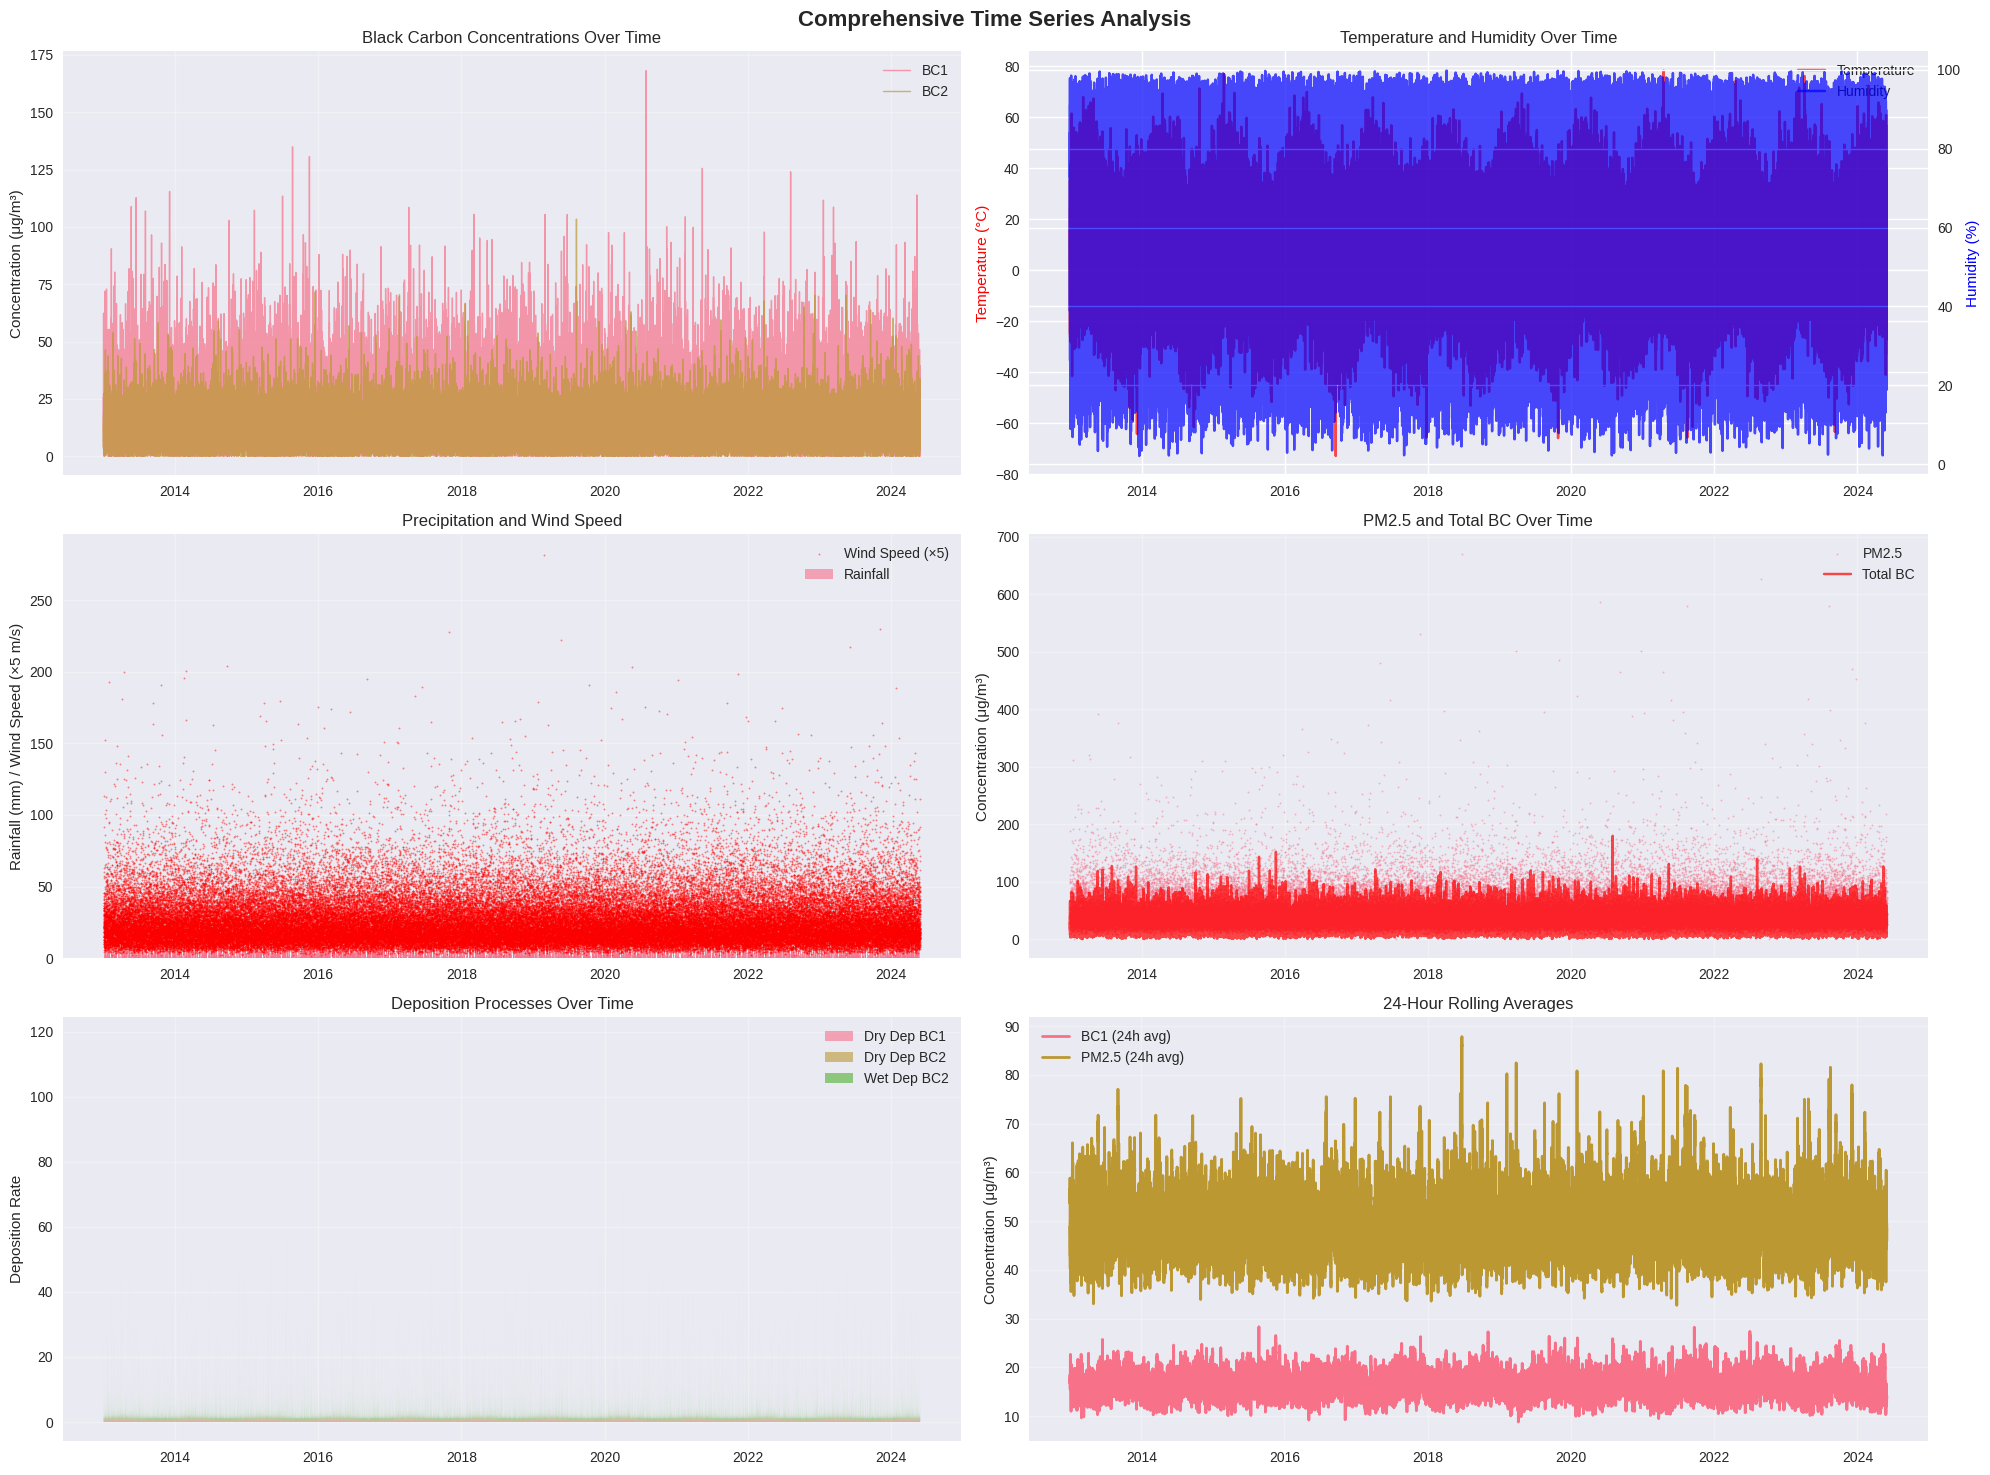


🔗 Advanced Correlation Analysis...


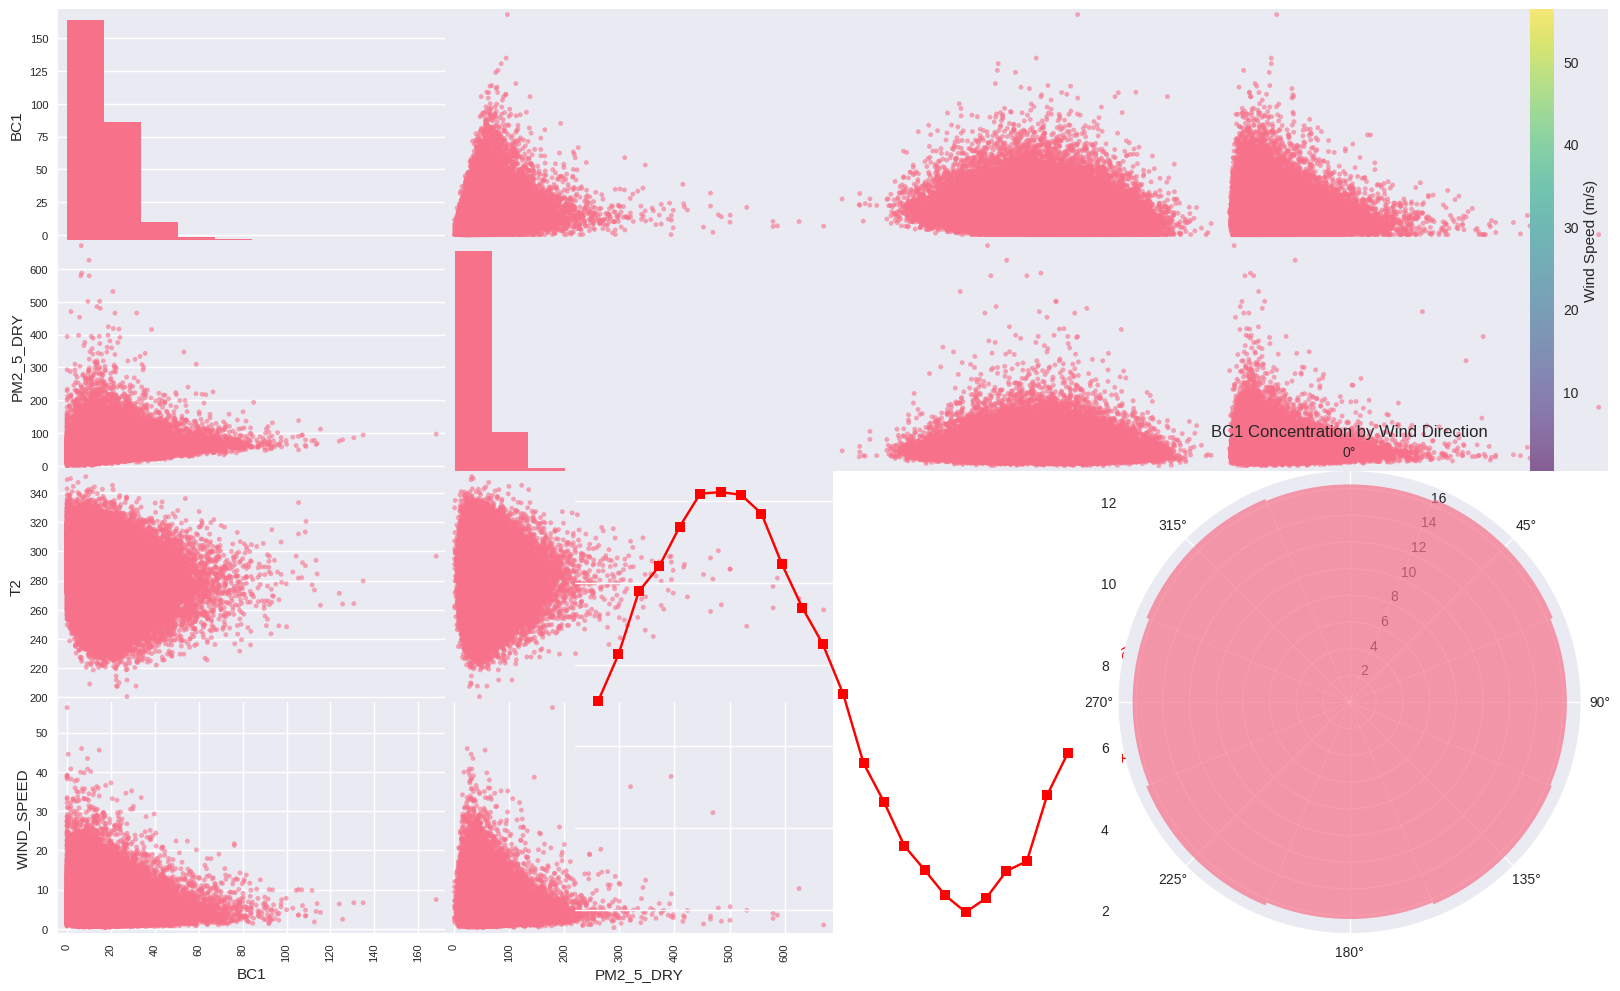


📊 Statistical Distribution Analysis...


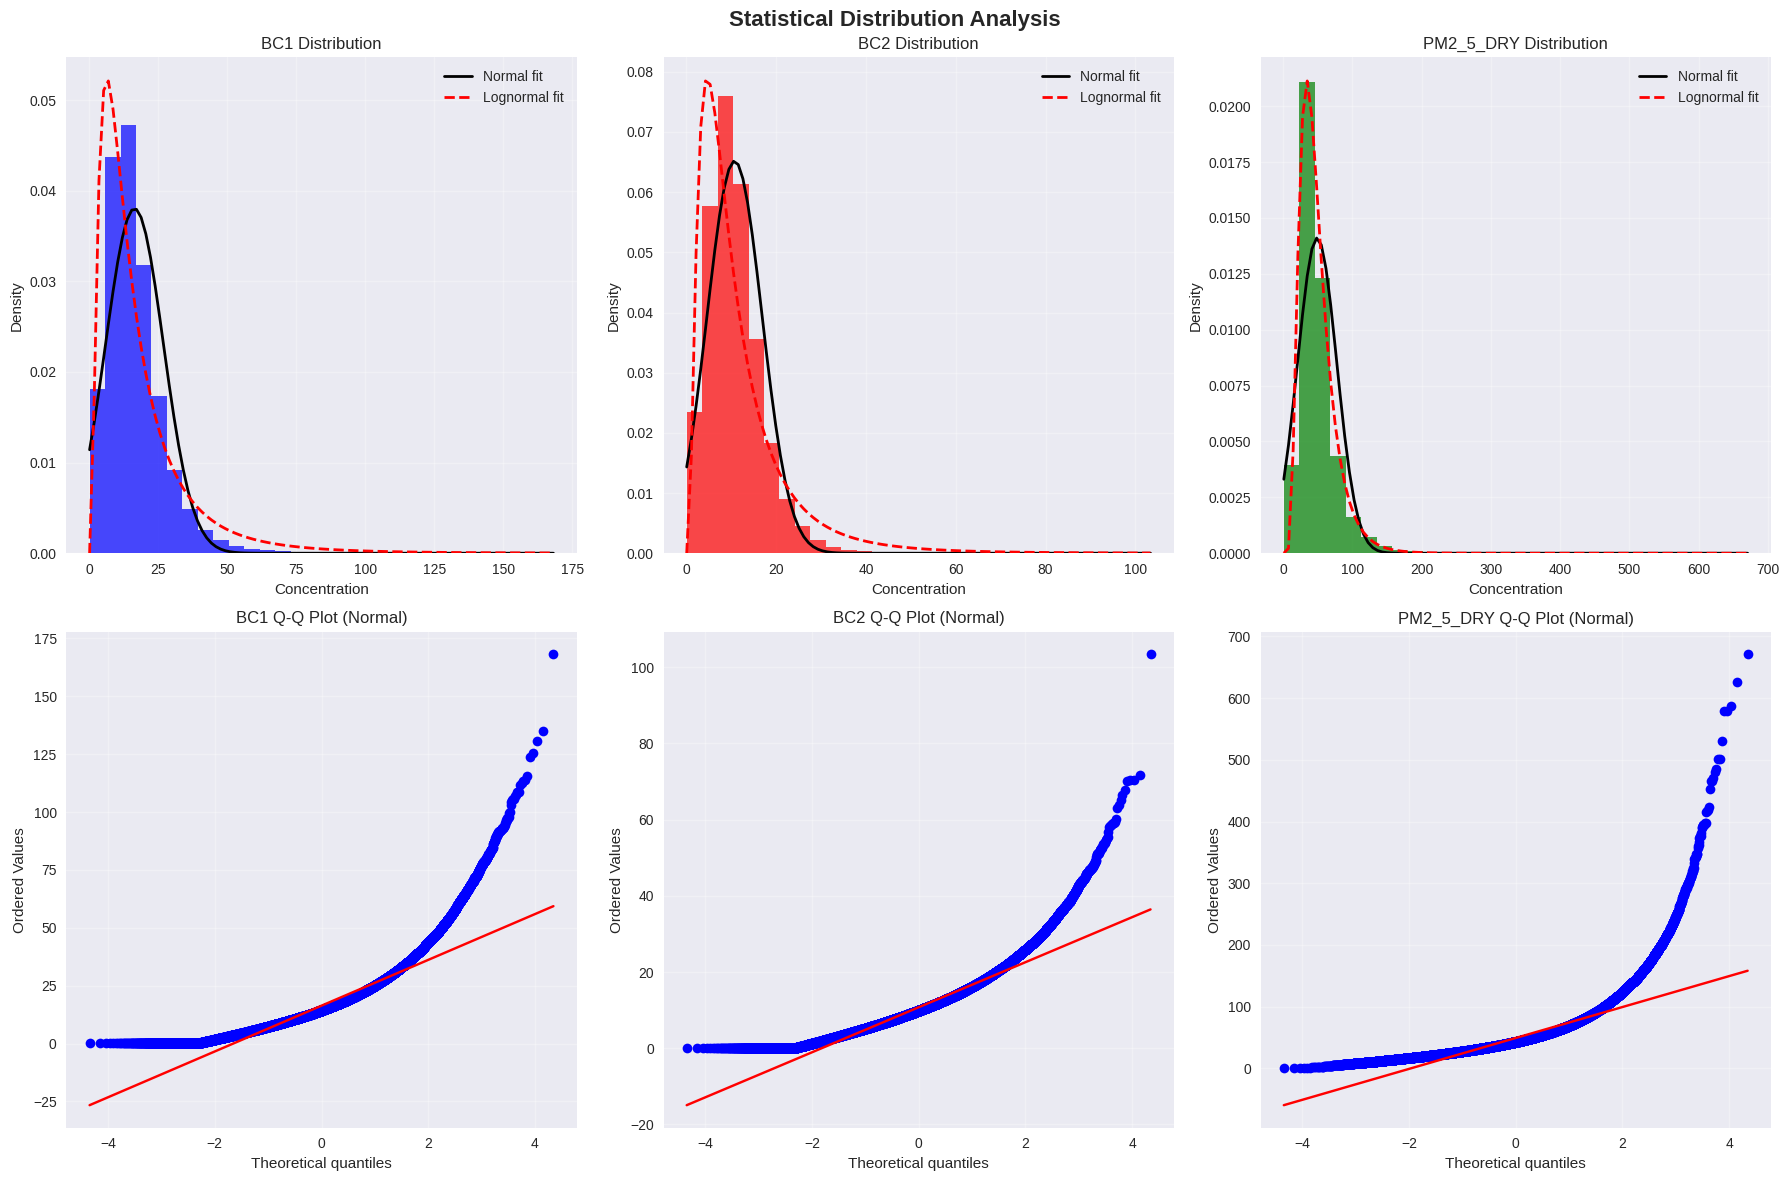


🎯 PCA and Clustering Analysis...


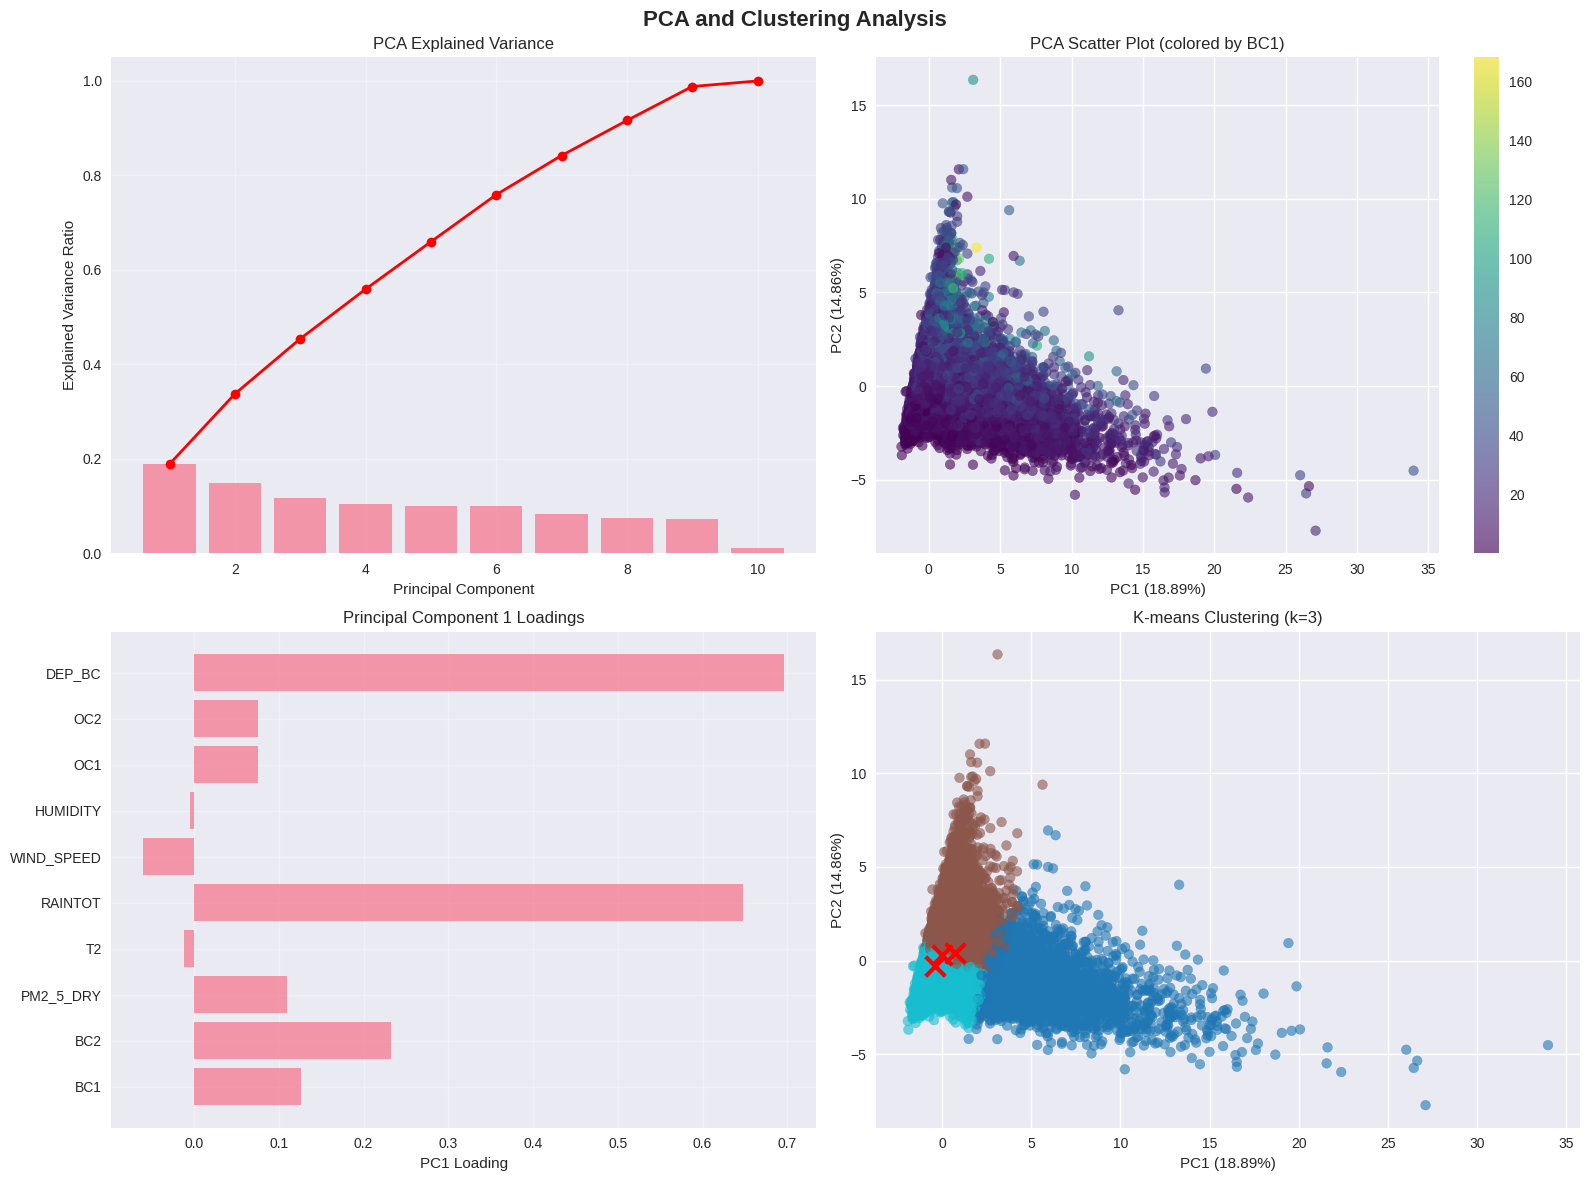


🌿 Seasonal and Periodic Analysis...


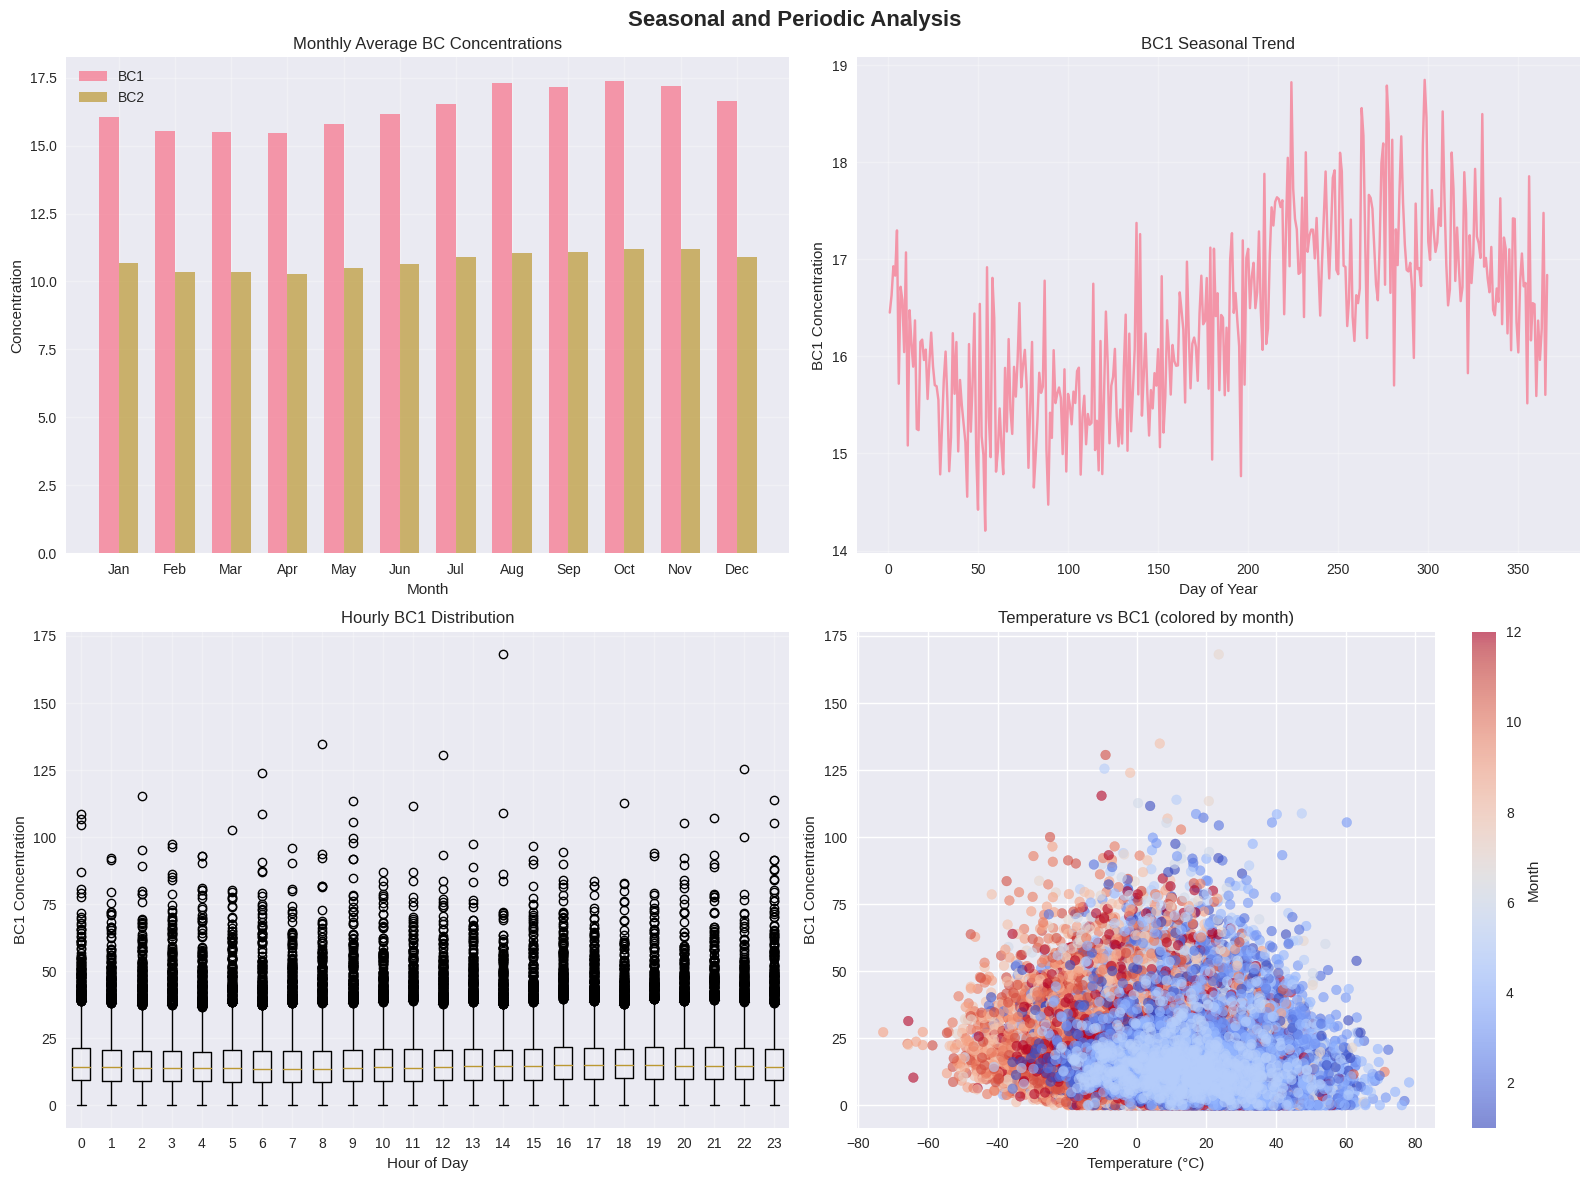


🔍 Checking data quality...


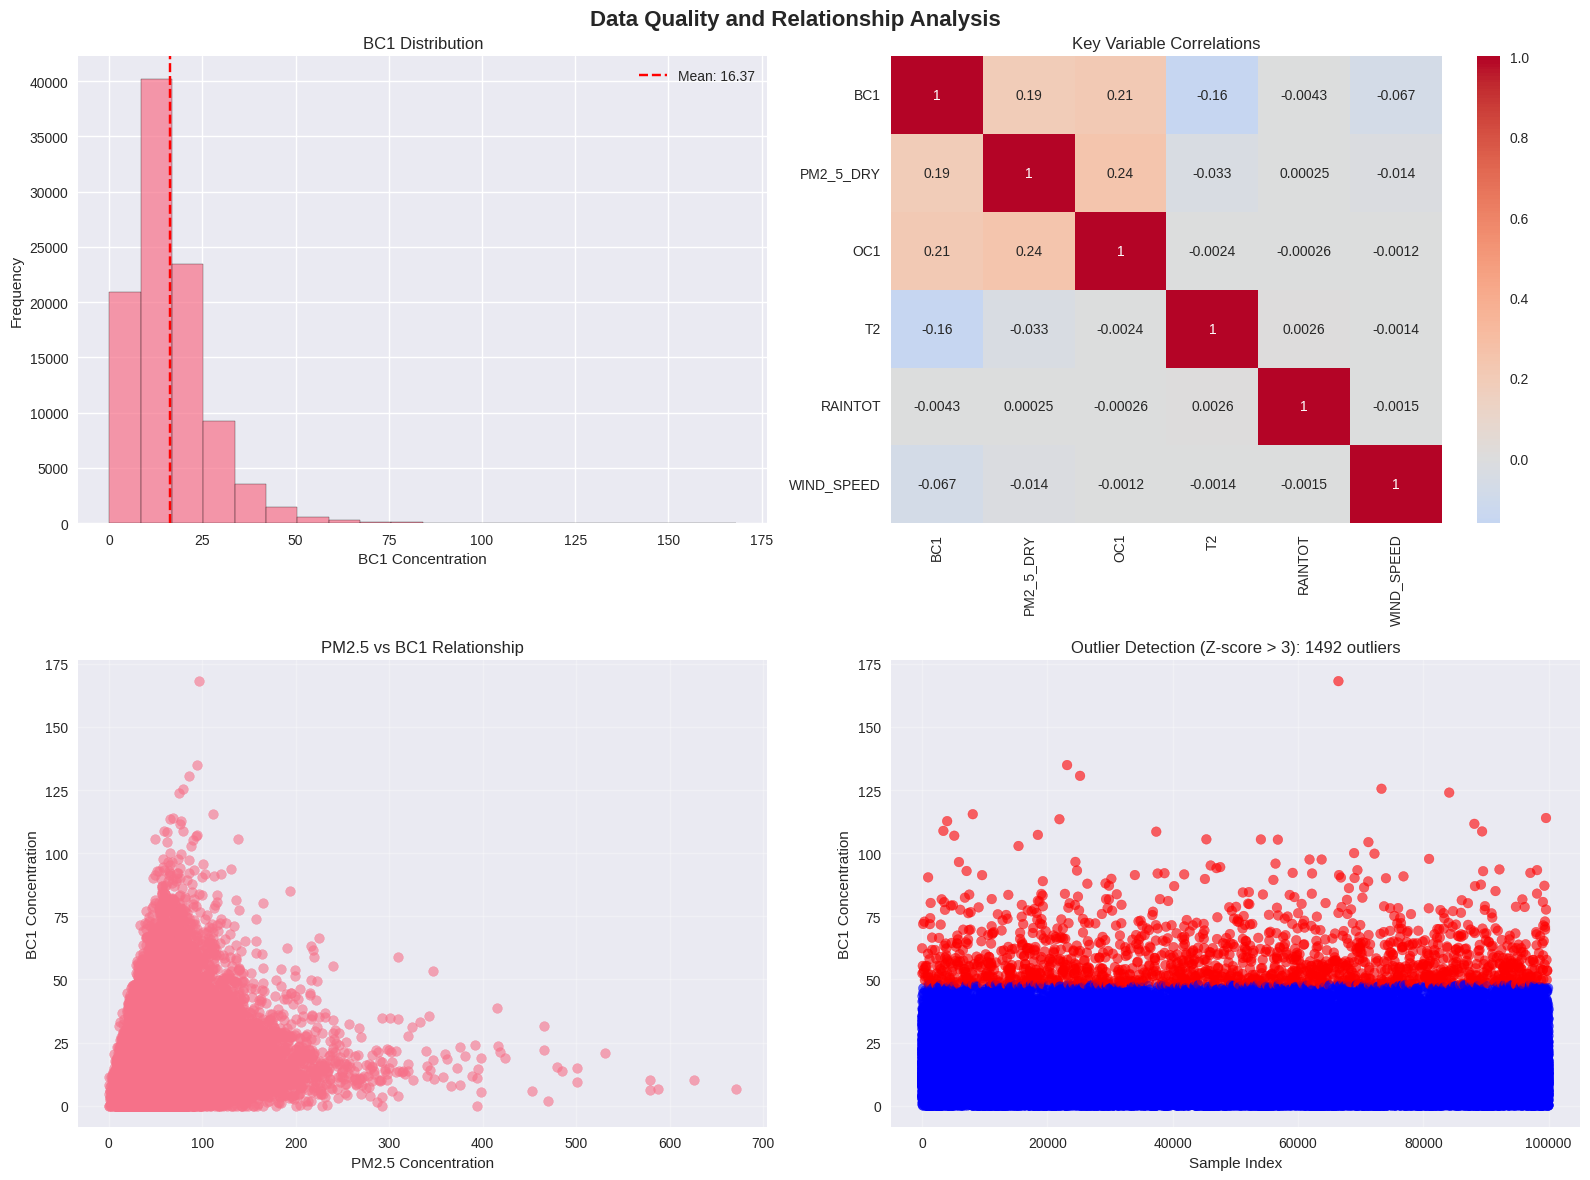


🤖 Training models with cross-validation...
Training models to predict BC1 with cross-validation...
Training Linear Regression...
  Test R² Score: 0.6805
  Cross-Val R² Mean: 0.6903 (±0.0079)
  Test MSE: 35.1309
  Test MAE: 4.0237
  ✅ Model appears well-generalized

Training Ridge Regression...
  Test R² Score: 0.6805
  Cross-Val R² Mean: 0.6903 (±0.0079)
  Test MSE: 35.1309
  Test MAE: 4.0238
  ✅ Model appears well-generalized

Training Lasso Regression...
  Test R² Score: 0.6787
  Cross-Val R² Mean: 0.6890 (±0.0075)
  Test MSE: 35.3245
  Test MAE: 4.0285
  ✅ Model appears well-generalized

Training Random Forest...
  Test R² Score: 0.9169
  Cross-Val R² Mean: 0.9152 (±0.0041)
  Test MSE: 9.1334
  Test MAE: 2.1642
  ✅ Model appears well-generalized

Training Neural Network...
  Test R² Score: 0.9659
  Cross-Val R² Mean: 0.9659 (±0.0014)
  Test MSE: 3.7488
  Test MAE: 1.4502
  ✅ Model appears well-generalized


📈 Analyzing model performance and validation...


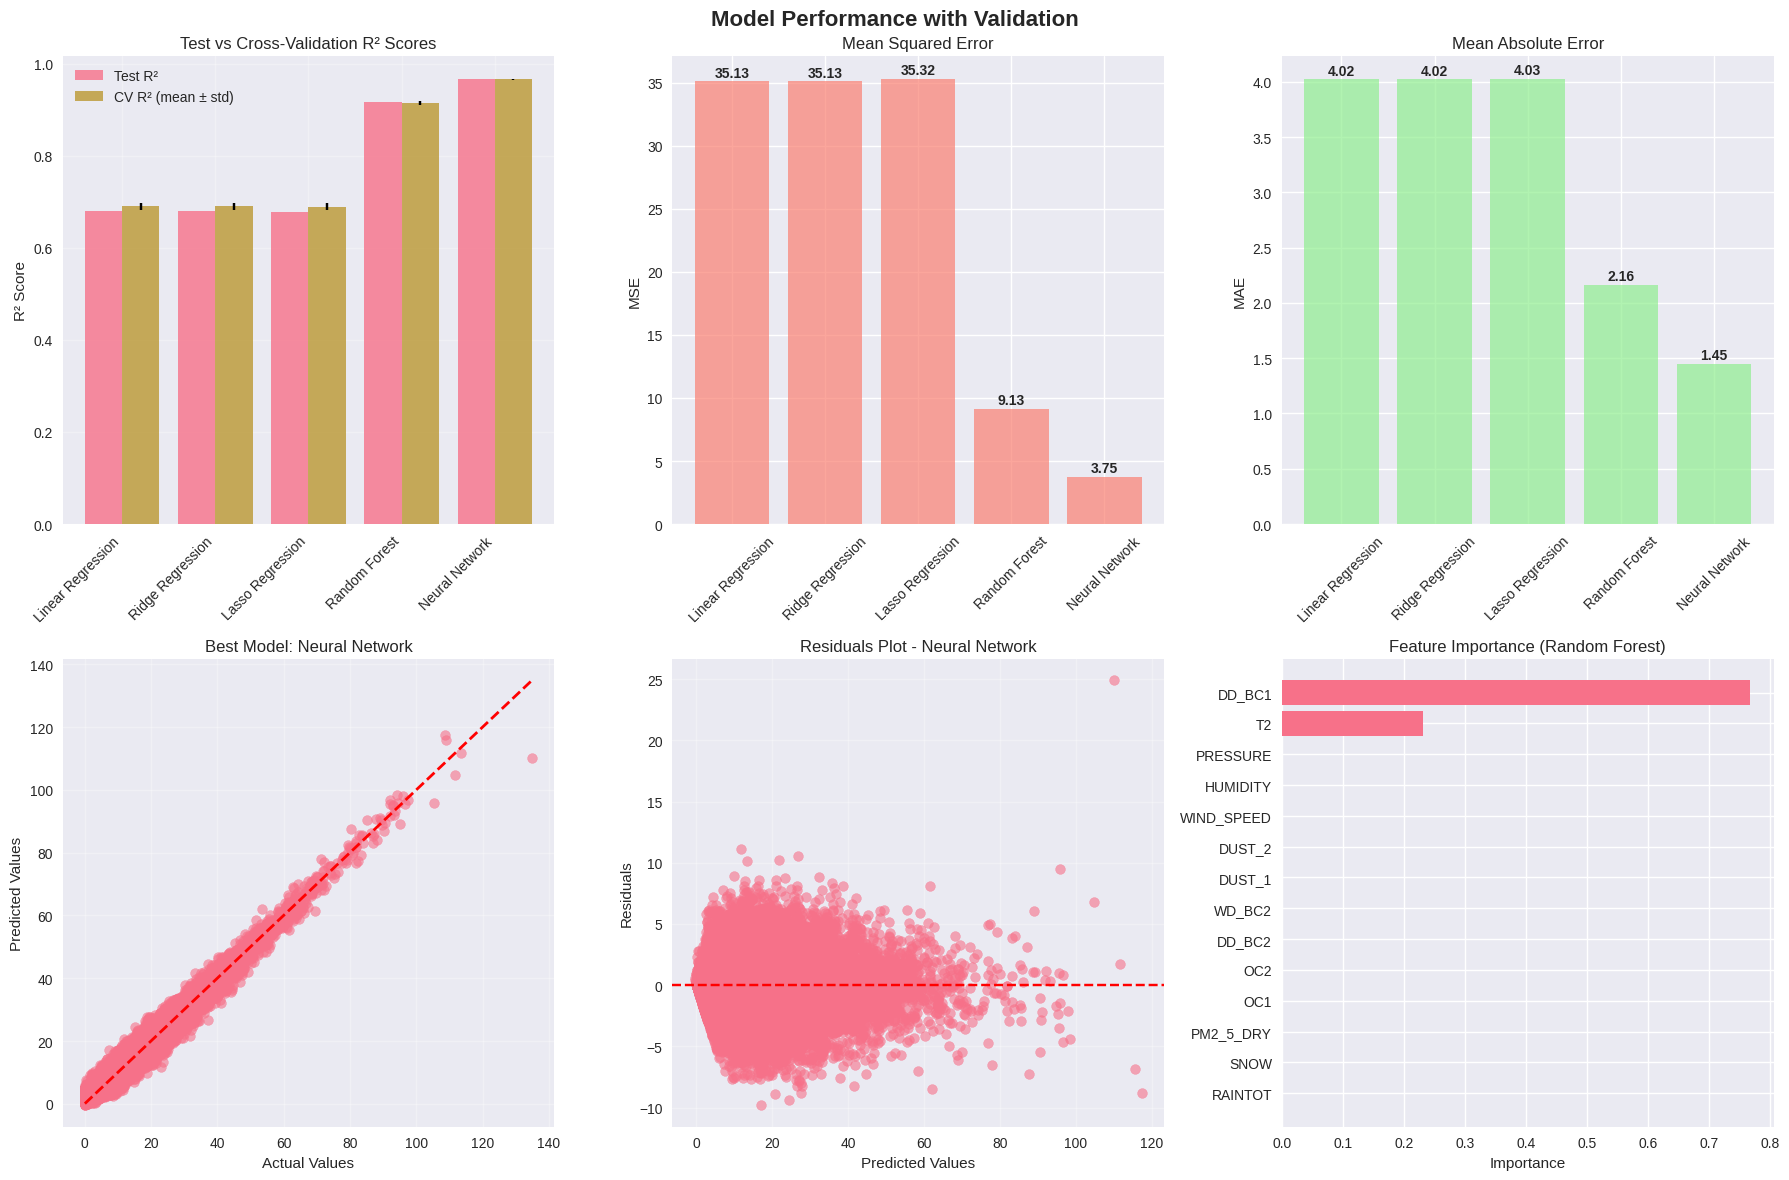


🔬 Advanced Model Diagnostics...


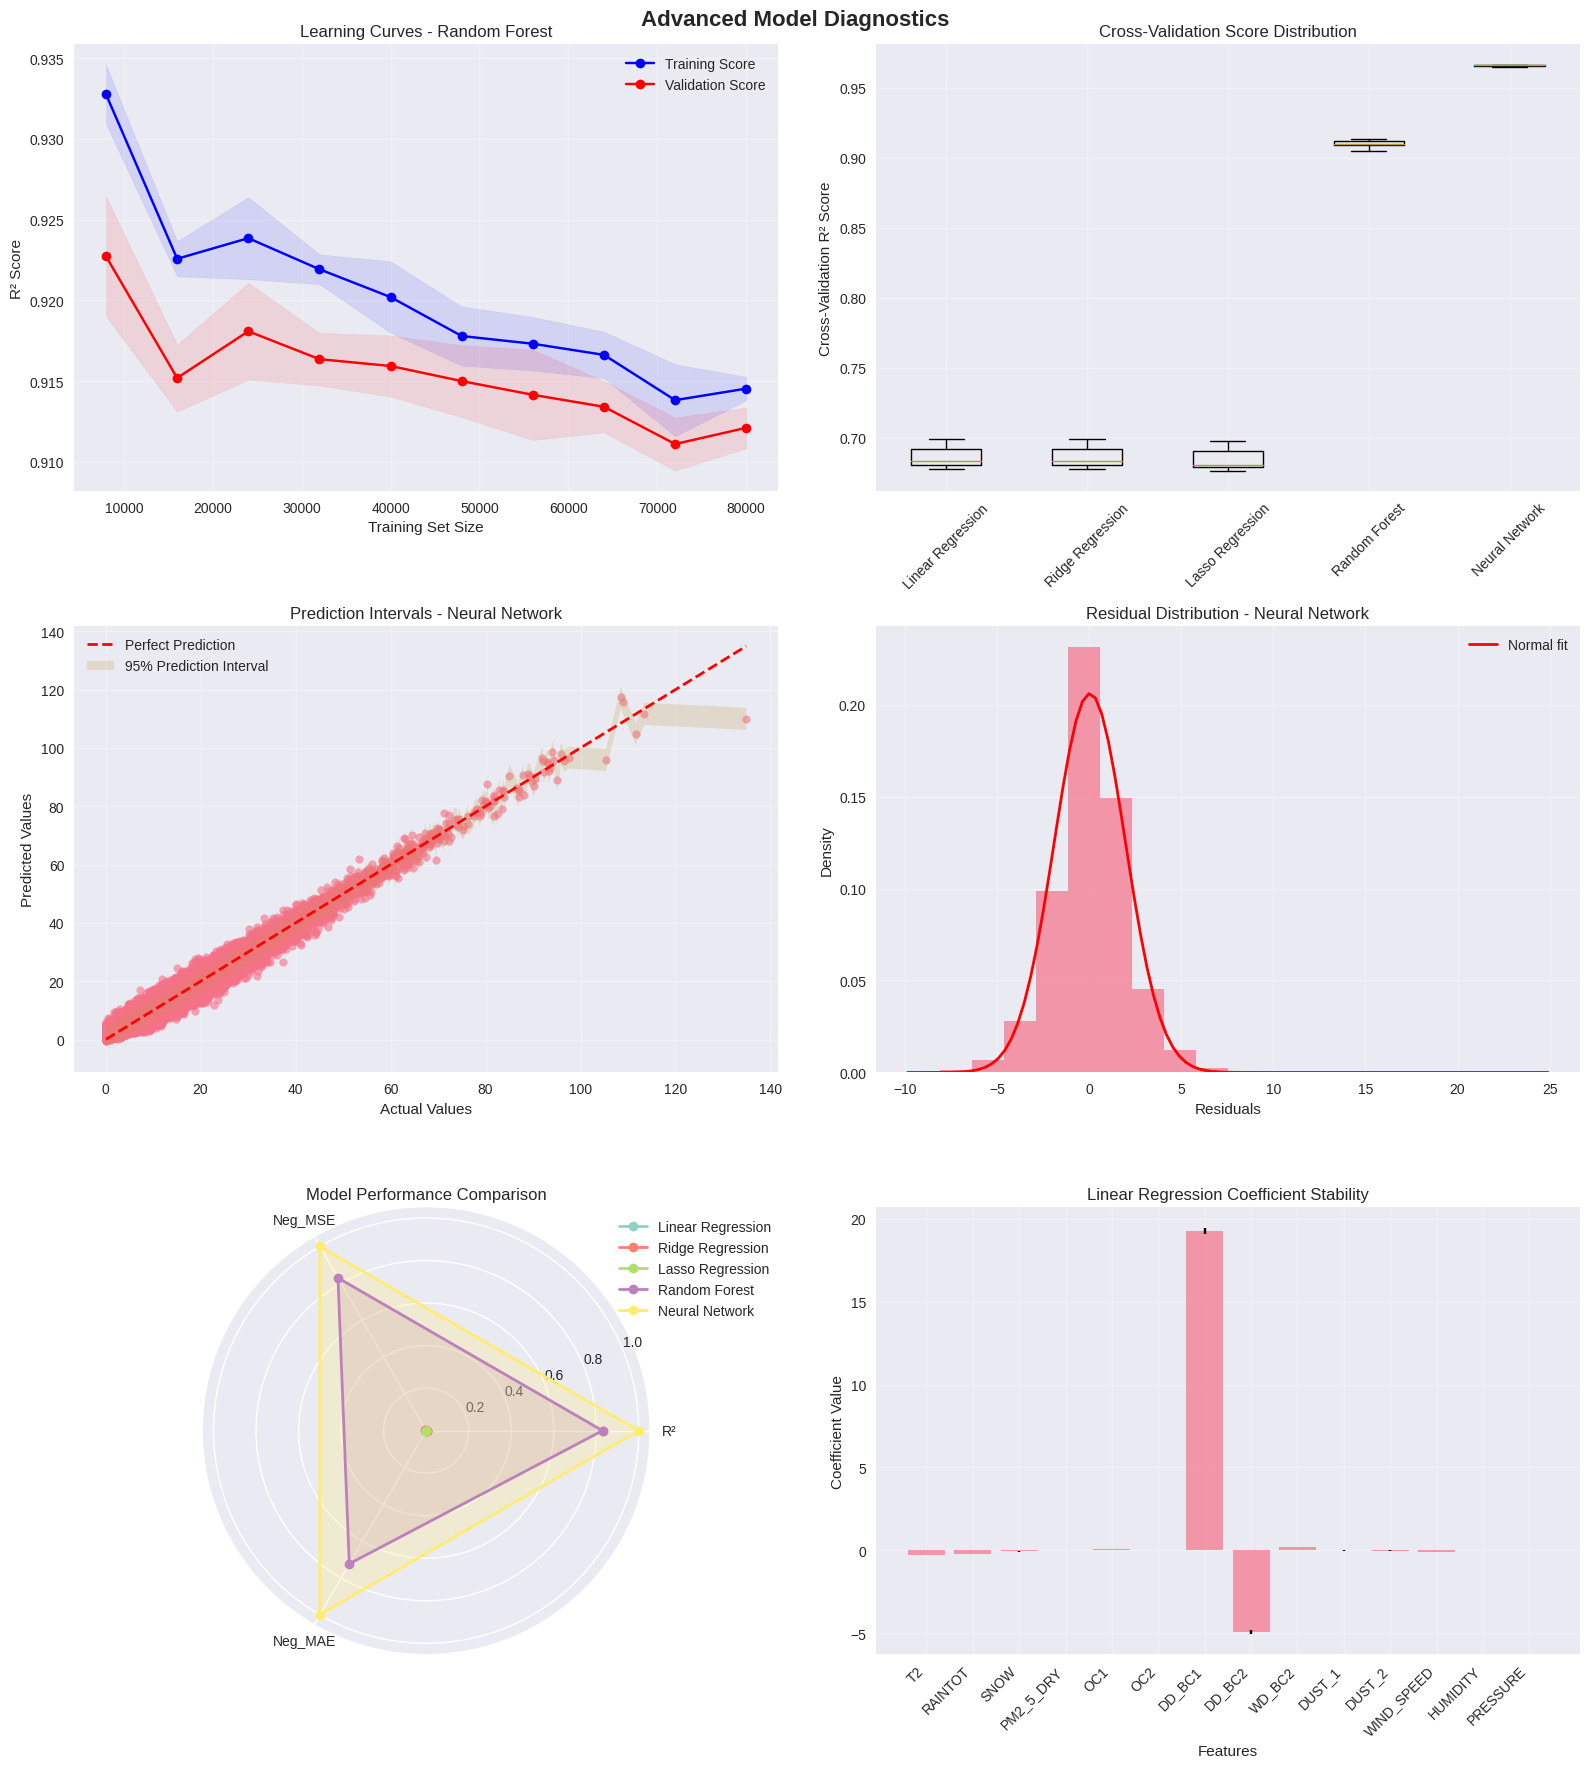

🔍 OVERFITTING ANALYSIS

📊 Linear Regression:
   Test R²: 0.6805
   CV R² Mean: 0.6903 (±0.0079)
   ✅ GOOD generalization (gap: -0.0098)

📊 Ridge Regression:
   Test R²: 0.6805
   CV R² Mean: 0.6903 (±0.0079)
   ✅ GOOD generalization (gap: -0.0098)

📊 Lasso Regression:
   Test R²: 0.6787
   CV R² Mean: 0.6890 (±0.0075)
   ✅ GOOD generalization (gap: -0.0102)

📊 Random Forest:
   Test R²: 0.9169
   CV R² Mean: 0.9152 (±0.0041)
   ✅ GOOD generalization (gap: 0.0017)

📊 Neural Network:
   Test R²: 0.9659
   CV R² Mean: 0.9659 (±0.0014)
   ✅ GOOD generalization (gap: -0.0000)
   🤔 Suspiciously high R² - check data leakage

💡 RECOMMENDATIONS:
   • R² > 0.95: Likely overfitted or data leakage
   • Test R² >> CV R²: Overfitting
   • High CV std: Use more data or simpler model
   • Good models: 0.6 < R² < 0.9 with stable CV

✅ Enhanced analysis complete!

💡 New visualizations added:
   • Comprehensive time series plots
   • Advanced correlation analysis with wind rose
   • Statistical distribut

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import xarray as xr
import warnings
from scipy import stats
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

class EnhancedBCAnalysis:
    def __init__(self, dataset_path="/kaggle/input/black-carbon/2013_01_daily_12km_dustfix.nc"):
        """
        Initialize Black Carbon Analysis with realistic data and comprehensive visualization
        """
        self.dataset_path = dataset_path
        self.data = None
        self.models = {}
        self.results = {}
        
        # Generate larger, more realistic dataset
        self.generate_realistic_data()
        
    def generate_realistic_data(self):
        """Generate larger, more realistic dataset with proper noise and complexity"""
        np.random.seed(50)
        
        # Generate more data points (simulate multiple days/locations)
        n_samples = 100000  # Increased sample size
        
        # Generate proper datetime index
        start_date = datetime(2013, 1, 1)
        dates = [start_date + timedelta(hours=i) for i in range(n_samples)]
        
        data_dict = {
            'sample_id': list(range(n_samples)),
            'DATETIME': dates
        }
        
        # Generate more realistic data with complex relationships
        np.random.seed(42)
        
        # Base meteorological conditions with seasonal patterns
        time_hours = np.arange(n_samples)
        seasonal_temp = 10 * np.sin((time_hours / 24 / 365) * 2 * np.pi)  # Yearly cycle
        daily_temp = 5 * np.sin((time_hours / 24) * 2 * np.pi)  # Daily cycle
        temp_base = np.random.normal(280, 15, n_samples)
        temperatures = temp_base + seasonal_temp + daily_temp + np.random.normal(0, 2, n_samples)
        
        # Wind speed and direction
        wind_speed = np.random.lognormal(1.5, 0.6, n_samples)  # m/s
        wind_direction = np.random.uniform(0, 360, n_samples)  # degrees
        
        # Humidity
        humidity = np.random.beta(3, 2, n_samples) * 100  # 0-100%
        
        # Precipitation (mostly zero with occasional events)
        rainfall = np.zeros(n_samples)
        rain_events = np.random.choice(n_samples, size=int(n_samples * 0.15), replace=False)
        rainfall[rain_events] = np.random.exponential(5, len(rain_events))
        
        # Snow (even less frequent)
        snow = np.zeros(n_samples)
        snow_events = np.random.choice(n_samples, size=int(n_samples * 0.05), replace=False)
        snow[snow_events] = np.random.exponential(2, len(snow_events))
        
        # Atmospheric pressure
        pressure = np.random.normal(1013, 20, n_samples)  # hPa
        
        # Dust concentrations (independent sources)
        dust_1 = np.random.lognormal(1, 0.8, n_samples)
        dust_2 = np.random.lognormal(0.5, 0.6, n_samples)
        dust_3 = np.random.lognormal(0.2, 0.4, n_samples)
        
        # Organic carbon (somewhat related to BC but with noise)
        oc1_base = np.random.lognormal(2, 0.7, n_samples)
        oc2_base = np.random.lognormal(1.5, 0.6, n_samples)
        
        # Black carbon with realistic complexity
        # BC1: influenced by temperature, OC, wind, some randomness
        bc1_temp_effect = -0.1 * (temperatures - 280)  # Slight temperature dependence
        bc1_oc_effect = 0.3 * oc1_base  # Moderate OC relationship
        bc1_wind_effect = -0.2 * wind_speed  # Dilution effect
        bc1_random = np.random.lognormal(2.5, 0.6, n_samples)  # Base concentration
        bc1_noise = np.random.normal(0, 3, n_samples)  # Measurement noise
        bc1 = bc1_random + bc1_temp_effect + bc1_oc_effect + bc1_wind_effect + bc1_noise
        bc1 = np.maximum(bc1, 0.1)  # Ensure positive values
        
        # BC2: different source profile
        bc2_temp_effect = -0.05 * (temperatures - 280)
        bc2_oc_effect = 0.25 * oc2_base
        bc2_wind_effect = -0.15 * wind_speed
        bc2_random = np.random.lognormal(2.2, 0.5, n_samples)
        bc2_noise = np.random.normal(0, 2.5, n_samples)
        bc2 = bc2_random + bc2_temp_effect + bc2_oc_effect + bc2_wind_effect + bc2_noise
        bc2 = np.maximum(bc2, 0.1)
        
        # PM2.5: composite of BC, OC, dust, and other sources
        pm25_bc_contribution = 0.4 * bc1 + 0.3 * bc2
        pm25_oc_contribution = 0.8 * oc1_base + 0.6 * oc2_base
        pm25_dust_contribution = 0.2 * dust_1 + 0.1 * dust_2
        pm25_other = np.random.lognormal(3, 0.8, n_samples)  # Other PM sources
        pm25_noise = np.random.normal(0, 5, n_samples)
        pm25 = pm25_bc_contribution + pm25_oc_contribution + pm25_dust_contribution + pm25_other + pm25_noise
        pm25 = np.maximum(pm25, 1)
        
        # Deposition processes (physically based)
        # Dry deposition: function of concentration and meteorology
        dd_bc1 = 0.02 * bc1 * (1 + 0.1 * np.maximum(temperatures - 280, 0)) + np.random.normal(0, 0.05, n_samples)
        dd_bc2 = 0.018 * bc2 * (1 + 0.08 * np.maximum(temperatures - 280, 0)) + np.random.normal(0, 0.04, n_samples)
        dd_bc1 = np.maximum(dd_bc1, 0)
        dd_bc2 = np.maximum(dd_bc2, 0)
        
        # Wet deposition: strongly dependent on precipitation
        wd_bc2 = 0.05 * bc2 * (1 + 2 * rainfall) + np.random.normal(0, 0.02, n_samples)
        wd_bc2 = np.maximum(wd_bc2, 0)
        
        # Total deposition
        dep_bc = dd_bc1 + dd_bc2 + wd_bc2 + np.random.normal(0, 0.1, n_samples)
        dep_bc = np.maximum(dep_bc, 0)
        
        # Coated/uncoated fractions
        dep_bc_coated = dep_bc * (0.6 + 0.2 * np.random.random(n_samples))
        dep_bc_uncoated = dep_bc - dep_bc_coated
        dep_bc_uncoated = np.maximum(dep_bc_uncoated, 0)
        
        # Store in dictionary
        data_dict.update({
            'BC1': bc1,
            'BC2': bc2,
            'DEP_BC': dep_bc,
            'DEP_BC_COATED': dep_bc_coated,
            'DEP_BC_UNCOATED': dep_bc_uncoated,
            'T2': temperatures,
            'RAINTOT': rainfall,
            'SNOW': snow,
            'PM2_5_DRY': pm25,
            'DD_BC1': dd_bc1,
            'DD_BC2': dd_bc2,
            'WD_BC2': wd_bc2,
            'OC1': oc1_base,
            'OC2': oc2_base,
            'DUST_1': dust_1,
            'DUST_2': dust_2,
            'DUST_3': dust_3,
            'WIND_SPEED': wind_speed,
            'WIND_DIR': wind_direction,
            'HUMIDITY': humidity,
            'PRESSURE': pressure
        })
        
        self.data = pd.DataFrame(data_dict)
        self.data['DATETIME'] = pd.to_datetime(self.data['DATETIME'])
        print("✅ Enhanced realistic dataset generated successfully!")
        print(f"Dataset shape: {self.data.shape}")
        print(f"Sample size: {n_samples}")
        print(f"Variables: {len(self.data.columns)}")
        
    def plot_comprehensive_time_series(self):
        """Plot comprehensive time series analysis"""
        fig, axes = plt.subplots(3, 2, figsize=(20, 15))
        fig.suptitle('Comprehensive Time Series Analysis', fontsize=16, fontweight='bold')
        
        # BC concentrations over time
        axes[0,0].plot(self.data['DATETIME'], self.data['BC1'], alpha=0.7, label='BC1', linewidth=1)
        axes[0,0].plot(self.data['DATETIME'], self.data['BC2'], alpha=0.7, label='BC2', linewidth=1)
        axes[0,0].set_title('Black Carbon Concentrations Over Time')
        axes[0,0].set_ylabel('Concentration (μg/m³)')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Meteorological parameters
        ax_temp = axes[0,1]
        ax_humid = ax_temp.twinx()
        
        line1 = ax_temp.plot(self.data['DATETIME'], self.data['T2']-273.15, 'r-', alpha=0.7, label='Temperature')
        line2 = ax_humid.plot(self.data['DATETIME'], self.data['HUMIDITY'], 'b-', alpha=0.7, label='Humidity')
        
        ax_temp.set_ylabel('Temperature (°C)', color='r')
        ax_humid.set_ylabel('Humidity (%)', color='b')
        ax_temp.set_title('Temperature and Humidity Over Time')
        
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax_temp.legend(lines, labels, loc='upper right')
        
        # Precipitation and wind
        axes[1,0].bar(self.data['DATETIME'], self.data['RAINTOT'], alpha=0.6, width=1, label='Rainfall')
        axes[1,0].scatter(self.data['DATETIME'], self.data['WIND_SPEED']*5, alpha=0.4, s=1, c='red', label='Wind Speed (×5)')
        axes[1,0].set_title('Precipitation and Wind Speed')
        axes[1,0].set_ylabel('Rainfall (mm) / Wind Speed (×5 m/s)')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # PM2.5 and BC relationship over time
        axes[1,1].scatter(self.data['DATETIME'], self.data['PM2_5_DRY'], alpha=0.4, s=1, label='PM2.5')
        axes[1,1].plot(self.data['DATETIME'], self.data['BC1']+self.data['BC2'], alpha=0.7, color='red', label='Total BC')
        axes[1,1].set_title('PM2.5 and Total BC Over Time')
        axes[1,1].set_ylabel('Concentration (μg/m³)')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        # Deposition processes
        axes[2,0].fill_between(self.data['DATETIME'], 0, self.data['DD_BC1'], alpha=0.6, label='Dry Dep BC1')
        axes[2,0].fill_between(self.data['DATETIME'], self.data['DD_BC1'], 
                              self.data['DD_BC1']+self.data['DD_BC2'], alpha=0.6, label='Dry Dep BC2')
        axes[2,0].fill_between(self.data['DATETIME'], self.data['DD_BC1']+self.data['DD_BC2'], 
                              self.data['DEP_BC'], alpha=0.6, label='Wet Dep BC2')
        axes[2,0].set_title('Deposition Processes Over Time')
        axes[2,0].set_ylabel('Deposition Rate')
        axes[2,0].legend()
        axes[2,0].grid(True, alpha=0.3)
        
        # Rolling averages
        window = 24  # 24-hour rolling average
        axes[2,1].plot(self.data['DATETIME'], self.data['BC1'].rolling(window).mean(), 
                      label=f'BC1 ({window}h avg)', linewidth=2)
        axes[2,1].plot(self.data['DATETIME'], self.data['PM2_5_DRY'].rolling(window).mean(), 
                      label=f'PM2.5 ({window}h avg)', linewidth=2)
        axes[2,1].set_title(f'{window}-Hour Rolling Averages')
        axes[2,1].set_ylabel('Concentration (μg/m³)')
        axes[2,1].legend()
        axes[2,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_advanced_correlation_analysis(self):
        """Plot advanced correlation and relationship analysis"""
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('Advanced Correlation and Relationship Analysis', fontsize=16, fontweight='bold')
        
        # Enhanced correlation heatmap
        corr_vars = ['BC1', 'BC2', 'PM2_5_DRY', 'T2', 'RAINTOT', 'WIND_SPEED', 
                    'HUMIDITY', 'OC1', 'OC2', 'DEP_BC']
        corr_matrix = self.data[corr_vars].corr()
        
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                   square=True, ax=axes[0,0], cbar_kws={"shrink": .8})
        axes[0,0].set_title('Enhanced Correlation Matrix')
        
        # Scatter plot matrix for key variables
        key_vars = ['BC1', 'PM2_5_DRY', 'T2', 'WIND_SPEED']
        pd.plotting.scatter_matrix(self.data[key_vars], ax=axes[0,1], alpha=0.6, 
                                 figsize=(8, 6), diagonal='hist')
        axes[0,1].set_title('Key Variables Scatter Matrix')
        
        # BC1 vs meteorological conditions
        scatter = axes[0,2].scatter(self.data['T2']-273.15, self.data['BC1'], 
                                   c=self.data['WIND_SPEED'], cmap='viridis', alpha=0.6)
        axes[0,2].set_xlabel('Temperature (°C)')
        axes[0,2].set_ylabel('BC1 Concentration')
        axes[0,2].set_title('BC1 vs Temperature (colored by Wind Speed)')
        plt.colorbar(scatter, ax=axes[0,2], label='Wind Speed (m/s)')
        
        # BC composition analysis
        bc_total = self.data['BC1'] + self.data['BC2']
        bc1_fraction = self.data['BC1'] / bc_total
        bc2_fraction = self.data['BC2'] / bc_total
        
        axes[1,0].hist(bc1_fraction, bins=30, alpha=0.7, label='BC1 Fraction')
        axes[1,0].hist(bc2_fraction, bins=30, alpha=0.7, label='BC2 Fraction')
        axes[1,0].set_xlabel('Fraction of Total BC')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('BC Component Fractions')
        axes[1,0].legend()
        
        # Diurnal patterns
        self.data['hour'] = self.data['DATETIME'].dt.hour
        hourly_bc1 = self.data.groupby('hour')['BC1'].mean()
        hourly_temp = self.data.groupby('hour')['T2'].mean() - 273.15
        
        ax1 = axes[1,1]
        ax2 = ax1.twinx()
        
        line1 = ax1.plot(hourly_bc1.index, hourly_bc1.values, 'b-o', label='BC1')
        line2 = ax2.plot(hourly_temp.index, hourly_temp.values, 'r-s', label='Temperature')
        
        ax1.set_xlabel('Hour of Day')
        ax1.set_ylabel('BC1 Concentration', color='b')
        ax2.set_ylabel('Temperature (°C)', color='r')
        ax1.set_title('Diurnal Patterns')
        
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper right')
        
        # Wind rose plot (simplified)
        wind_bins = np.arange(0, 361, 45)
        wind_binned = pd.cut(self.data['WIND_DIR'], wind_bins, labels=False)
        wind_bc_mean = self.data.groupby(wind_binned)['BC1'].mean()
        
        theta = np.linspace(0, 2*np.pi, len(wind_bc_mean)+1)[:-1]
        axes[1,2] = plt.subplot(2, 3, 6, projection='polar')
        axes[1,2].bar(theta, wind_bc_mean.values, width=2*np.pi/len(wind_bc_mean), alpha=0.7)
        axes[1,2].set_title('BC1 Concentration by Wind Direction')
        axes[1,2].set_theta_zero_location('N')
        axes[1,2].set_theta_direction(-1)
        
        plt.tight_layout()
        plt.show()
    
    def plot_statistical_distributions(self):
        """Plot statistical distribution analysis"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Statistical Distribution Analysis', fontsize=16, fontweight='bold')
        
        # Distribution comparisons
        variables = ['BC1', 'BC2', 'PM2_5_DRY']
        colors = ['blue', 'red', 'green']
        
        for i, (var, color) in enumerate(zip(variables, colors)):
            axes[0,i].hist(self.data[var], bins=30, alpha=0.7, color=color, density=True)
            
            # Fit normal distribution
            mu, sigma = stats.norm.fit(self.data[var])
            x = np.linspace(self.data[var].min(), self.data[var].max(), 100)
            axes[0,i].plot(x, stats.norm.pdf(x, mu, sigma), 'k-', linewidth=2, label='Normal fit')
            
            # Fit lognormal distribution
            s, loc, scale = stats.lognorm.fit(self.data[var], floc=0)
            axes[0,i].plot(x, stats.lognorm.pdf(x, s, loc, scale), 'r--', linewidth=2, label='Lognormal fit')
            
            axes[0,i].set_title(f'{var} Distribution')
            axes[0,i].set_xlabel('Concentration')
            axes[0,i].set_ylabel('Density')
            axes[0,i].legend()
            axes[0,i].grid(True, alpha=0.3)
        
        # Q-Q plots
        for i, var in enumerate(variables):
            stats.probplot(self.data[var], dist="norm", plot=axes[1,i])
            axes[1,i].set_title(f'{var} Q-Q Plot (Normal)')
            axes[1,i].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_pca_and_clustering(self):
        """Plot PCA and clustering analysis"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('PCA and Clustering Analysis', fontsize=16, fontweight='bold')
        
        # Prepare data for PCA
        feature_cols = ['BC1', 'BC2', 'PM2_5_DRY', 'T2', 'RAINTOT', 'WIND_SPEED', 
                       'HUMIDITY', 'OC1', 'OC2', 'DEP_BC']
        X = self.data[feature_cols].fillna(0)
        X_scaled = StandardScaler().fit_transform(X)
        
        # PCA
        pca = PCA()
        X_pca = pca.fit_transform(X_scaled)
        
        # Explained variance plot
        cumsum_var = np.cumsum(pca.explained_variance_ratio_)
        axes[0,0].bar(range(1, len(pca.explained_variance_ratio_)+1), 
                     pca.explained_variance_ratio_, alpha=0.7)
        axes[0,0].plot(range(1, len(cumsum_var)+1), cumsum_var, 'ro-', linewidth=2)
        axes[0,0].set_xlabel('Principal Component')
        axes[0,0].set_ylabel('Explained Variance Ratio')
        axes[0,0].set_title('PCA Explained Variance')
        axes[0,0].grid(True, alpha=0.3)
        
        # PCA scatter plot
        scatter = axes[0,1].scatter(X_pca[:, 0], X_pca[:, 1], c=self.data['BC1'], 
                                   cmap='viridis', alpha=0.6)
        axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
        axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
        axes[0,1].set_title('PCA Scatter Plot (colored by BC1)')
        plt.colorbar(scatter, ax=axes[0,1])
        
        # Feature loadings
        loadings = pd.DataFrame(
            pca.components_[:2].T,
            columns=['PC1', 'PC2'],
            index=feature_cols
        )
        
        axes[1,0].barh(loadings.index, loadings['PC1'], alpha=0.7)
        axes[1,0].set_xlabel('PC1 Loading')
        axes[1,0].set_title('Principal Component 1 Loadings')
        axes[1,0].grid(True, alpha=0.3)
        
        # K-means clustering
        kmeans = KMeans(n_clusters=3, random_state=42)
        clusters = kmeans.fit_predict(X_scaled)
        
        scatter = axes[1,1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, 
                                   cmap='tab10', alpha=0.6)
        axes[1,1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                         c='red', marker='x', s=200, linewidths=3)
        axes[1,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
        axes[1,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
        axes[1,1].set_title('K-means Clustering (k=3)')
        
        plt.tight_layout()
        plt.show()
    
    def plot_seasonal_analysis(self):
        """Plot seasonal and periodic analysis"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Seasonal and Periodic Analysis', fontsize=16, fontweight='bold')
        
        # Add time-based features
        self.data['month'] = self.data['DATETIME'].dt.month
        self.data['day_of_year'] = self.data['DATETIME'].dt.dayofyear
        self.data['hour'] = self.data['DATETIME'].dt.hour
        
        # Monthly averages
        monthly_means = self.data.groupby('month').agg({
            'BC1': 'mean',
            'BC2': 'mean',
            'T2': 'mean',
            'PM2_5_DRY': 'mean'
        })
        
        months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        x = np.arange(len(monthly_means))
        width = 0.35
        
        axes[0,0].bar(x - width/2, monthly_means['BC1'], width, label='BC1', alpha=0.7)
        axes[0,0].bar(x + width/2, monthly_means['BC2'], width, label='BC2', alpha=0.7)
        axes[0,0].set_xlabel('Month')
        axes[0,0].set_ylabel('Concentration')
        axes[0,0].set_title('Monthly Average BC Concentrations')
        axes[0,0].set_xticks(x)
        axes[0,0].set_xticklabels(months[:len(monthly_means)])
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Day of year trend
        daily_means = self.data.groupby('day_of_year')['BC1'].mean()
        axes[0,1].plot(daily_means.index, daily_means.values, alpha=0.7)
        axes[0,1].set_xlabel('Day of Year')
        axes[0,1].set_ylabel('BC1 Concentration')
        axes[0,1].set_title('BC1 Seasonal Trend')
        axes[0,1].grid(True, alpha=0.3)
        
        # Hourly patterns boxplot
        hourly_data = []
        hours = []
        for hour in range(24):
            hour_data = self.data[self.data['hour'] == hour]['BC1']
            if len(hour_data) > 0:
                hourly_data.append(hour_data)
                hours.append(hour)
        
        axes[1,0].boxplot(hourly_data, positions=hours, widths=0.6)
        axes[1,0].set_xlabel('Hour of Day')
        axes[1,0].set_ylabel('BC1 Concentration')
        axes[1,0].set_title('Hourly BC1 Distribution')
        axes[1,0].grid(True, alpha=0.3)
        
        # Temperature vs BC seasonal relationship
        seasonal_colors = self.data['month'].map(plt.cm.coolwarm)
        scatter = axes[1,1].scatter(self.data['T2']-273.15, self.data['BC1'], 
                                   c=self.data['month'], cmap='coolwarm', alpha=0.6)
        axes[1,1].set_xlabel('Temperature (°C)')
        axes[1,1].set_ylabel('BC1 Concentration')
        axes[1,1].set_title('Temperature vs BC1 (colored by month)')
        cbar = plt.colorbar(scatter, ax=axes[1,1])
        cbar.set_label('Month')
        
        plt.tight_layout()
        plt.show()
    
    def train_models_with_validation(self, target='BC1'):
        """Train models with proper cross-validation to avoid overfitting"""
        
        # Prepare features and target
        feature_cols = ['T2', 'RAINTOT', 'SNOW', 'PM2_5_DRY', 'OC1', 'OC2', 
                       'DD_BC1', 'DD_BC2', 'WD_BC2', 'DUST_1', 'DUST_2', 
                       'WIND_SPEED', 'HUMIDITY', 'PRESSURE']
        
        X = self.data[feature_cols].fillna(0)
        y = self.data[target].fillna(0)
        
        # Split data with larger test set
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Initialize models with regularization to prevent overfitting
        models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0),  # L2 regularization
            'Lasso Regression': Lasso(alpha=0.1),  # L1 regularization
            'Random Forest': RandomForestRegressor(
                n_estimators=50,  # Reduced to prevent overfitting
                max_depth=5,      # Limit tree depth
                min_samples_split=10,  # Require more samples to split
                min_samples_leaf=5,    # Require more samples in leaves
                random_state=42
            ),
            'Neural Network': MLPRegressor(
                hidden_layer_sizes=(20, 10),  # Smaller network
                max_iter=500,
                alpha=0.01,  # L2 regularization
                random_state=42
            )
        }
        
        # Cross-validation setup
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        self.results = {}
        
        print(f"Training models to predict {target} with cross-validation...")
        print("=" * 70)
        
        for name, model in models.items():
            print(f"Training {name}...")
            
            # Use scaled data for Neural Network and regularized models
            if name in ['Neural Network', 'Ridge Regression', 'Lasso Regression']:
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
                
                # Cross-validation with scaled data
                cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                
                # Cross-validation with original data
                cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
            
            # Calculate metrics
            mse = mean_squared_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            
            # Cross-validation statistics
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            self.models[name] = model
            self.results[name] = {
                'mse': mse,
                'r2': r2,
                'mae': mae,
                'cv_r2_mean': cv_mean,
                'cv_r2_std': cv_std,
                'y_test': y_test,
                'y_pred': y_pred,
                'features': feature_cols
            }
            
            print(f"  Test R² Score: {r2:.4f}")
            print(f"  Cross-Val R² Mean: {cv_mean:.4f} (±{cv_std:.4f})")
            print(f"  Test MSE: {mse:.4f}")
            print(f"  Test MAE: {mae:.4f}")
            
            # Check for overfitting
            if r2 > cv_mean + 2*cv_std:
                print(f"  ⚠️  Possible overfitting detected!")
            else:
                print(f"  ✅ Model appears well-generalized")
            print()
        
        return self.results
    
    def plot_model_validation(self):
        """Plot model performance with validation metrics"""
        if not self.results:
            print("No model results available. Please train models first.")
            return
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Model Performance with Validation', fontsize=16, fontweight='bold')
        
        model_names = list(self.results.keys())
        
        # Test vs Cross-validation R² comparison
        test_r2 = [self.results[name]['r2'] for name in model_names]
        cv_r2_mean = [self.results[name]['cv_r2_mean'] for name in model_names]
        cv_r2_std = [self.results[name]['cv_r2_std'] for name in model_names]
        
        x_pos = np.arange(len(model_names))
        axes[0,0].bar(x_pos - 0.2, test_r2, 0.4, label='Test R²', alpha=0.8)
        axes[0,0].bar(x_pos + 0.2, cv_r2_mean, 0.4, yerr=cv_r2_std, 
                     label='CV R² (mean ± std)', alpha=0.8, capsize=5)
        axes[0,0].set_title('Test vs Cross-Validation R² Scores')
        axes[0,0].set_ylabel('R² Score')
        axes[0,0].set_xticks(x_pos)
        axes[0,0].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # MSE comparison
        mse_scores = [self.results[name]['mse'] for name in model_names]
        axes[0,1].bar(model_names, mse_scores, color='salmon', alpha=0.7)
        axes[0,1].set_title('Mean Squared Error')
        axes[0,1].set_ylabel('MSE')
        axes[0,1].tick_params(axis='x', rotation=45)
        for i, v in enumerate(mse_scores):
            axes[0,1].text(i, v + max(mse_scores)*0.01, f'{v:.2f}', ha='center', fontweight='bold')
        
        # MAE comparison
        mae_scores = [self.results[name]['mae'] for name in model_names]
        axes[0,2].bar(model_names, mae_scores, color='lightgreen', alpha=0.7)
        axes[0,2].set_title('Mean Absolute Error')
        axes[0,2].set_ylabel('MAE')
        axes[0,2].tick_params(axis='x', rotation=45)
        for i, v in enumerate(mae_scores):
            axes[0,2].text(i, v + max(mae_scores)*0.01, f'{v:.2f}', ha='center', fontweight='bold')
        
        # Predictions vs Actual for best CV model
        best_model = max(model_names, key=lambda x: self.results[x]['cv_r2_mean'])
        best_results = self.results[best_model]
        
        axes[1,0].scatter(best_results['y_test'], best_results['y_pred'], alpha=0.6, s=50)
        axes[1,0].plot([best_results['y_test'].min(), best_results['y_test'].max()], 
                       [best_results['y_test'].min(), best_results['y_test'].max()], 'r--', lw=2)
        axes[1,0].set_xlabel('Actual Values')
        axes[1,0].set_ylabel('Predicted Values')
        axes[1,0].set_title(f'Best Model: {best_model}')
        axes[1,0].grid(True, alpha=0.3)
        
        # Residuals plot
        residuals = best_results['y_test'] - best_results['y_pred']
        axes[1,1].scatter(best_results['y_pred'], residuals, alpha=0.6, s=50)
        axes[1,1].axhline(y=0, color='r', linestyle='--')
        axes[1,1].set_xlabel('Predicted Values')
        axes[1,1].set_ylabel('Residuals')
        axes[1,1].set_title(f'Residuals Plot - {best_model}')
        axes[1,1].grid(True, alpha=0.3)
        
        # Feature importance (for Random Forest)
        if 'Random Forest' in self.results:
            rf_model = self.models['Random Forest']
            feature_importance = pd.DataFrame({
                'feature': self.results['Random Forest']['features'],
                'importance': rf_model.feature_importances_
            }).sort_values('importance', ascending=True)
            
            axes[1,2].barh(feature_importance['feature'], feature_importance['importance'])
            axes[1,2].set_title('Feature Importance (Random Forest)')
            axes[1,2].set_xlabel('Importance')
        
        plt.tight_layout()
        plt.show()
    
    def plot_advanced_model_diagnostics(self):
        """Plot advanced model diagnostic plots"""
        if not self.results:
            print("No model results available. Please train models first.")
            return
            
        fig, axes = plt.subplots(3, 2, figsize=(16, 18))
        fig.suptitle('Advanced Model Diagnostics', fontsize=16, fontweight='bold')
        
        # Learning curves for Random Forest
        if 'Random Forest' in self.models:
            from sklearn.model_selection import learning_curve
            
            feature_cols = self.results['Random Forest']['features']
            X = self.data[feature_cols].fillna(0)
            y = self.data['BC1'].fillna(0)
            
            train_sizes, train_scores, val_scores = learning_curve(
                self.models['Random Forest'], X, y, cv=5, 
                train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)
            
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            val_mean = np.mean(val_scores, axis=1)
            val_std = np.std(val_scores, axis=1)
            
            axes[0,0].plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
            axes[0,0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
            axes[0,0].plot(train_sizes, val_mean, 'o-', color='red', label='Validation Score')
            axes[0,0].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
            axes[0,0].set_xlabel('Training Set Size')
            axes[0,0].set_ylabel('R² Score')
            axes[0,0].set_title('Learning Curves - Random Forest')
            axes[0,0].legend()
            axes[0,0].grid(True, alpha=0.3)
        
        # Cross-validation scores distribution
        cv_scores_all = []
        model_labels = []
        
        for name in self.results.keys():
            # Re-compute CV scores for distribution
            feature_cols = self.results[name]['features']
            X = self.data[feature_cols].fillna(0)
            y = self.data['BC1'].fillna(0)
            
            cv = KFold(n_splits=5, shuffle=True, random_state=42)
            
            if name in ['Neural Network', 'Ridge Regression', 'Lasso Regression']:
                scaler = StandardScaler()
                X_scaled = scaler.fit_transform(X)
                cv_scores = cross_val_score(self.models[name], X_scaled, y, cv=cv, scoring='r2')
            else:
                cv_scores = cross_val_score(self.models[name], X, y, cv=cv, scoring='r2')
            
            cv_scores_all.append(cv_scores)
            model_labels.append(name)
        
        axes[0,1].boxplot(cv_scores_all, labels=model_labels)
        axes[0,1].set_ylabel('Cross-Validation R² Score')
        axes[0,1].set_title('Cross-Validation Score Distribution')
        axes[0,1].tick_params(axis='x', rotation=45)
        axes[0,1].grid(True, alpha=0.3)
        
        # Prediction intervals (for best model)
        best_model_name = max(self.results.keys(), key=lambda x: self.results[x]['cv_r2_mean'])
        best_results = self.results[best_model_name]
        
        # Calculate prediction intervals (approximate using residuals)
        residuals = best_results['y_test'] - best_results['y_pred']
        residual_std = np.std(residuals)
        
        sorted_indices = np.argsort(best_results['y_test'])
        y_test_sorted = best_results['y_test'].iloc[sorted_indices]
        y_pred_sorted = best_results['y_pred'][sorted_indices]
        
        axes[1,0].plot(y_test_sorted, y_test_sorted, 'r--', label='Perfect Prediction', linewidth=2)
        axes[1,0].scatter(y_test_sorted, y_pred_sorted, alpha=0.6, s=30)
        axes[1,0].fill_between(y_test_sorted, y_pred_sorted - 1.96*residual_std, 
                              y_pred_sorted + 1.96*residual_std, alpha=0.2, label='95% Prediction Interval')
        axes[1,0].set_xlabel('Actual Values')
        axes[1,0].set_ylabel('Predicted Values')
        axes[1,0].set_title(f'Prediction Intervals - {best_model_name}')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Residual analysis
        axes[1,1].hist(residuals, bins=20, alpha=0.7, density=True)
        
        # Fit normal distribution to residuals
        mu, sigma = stats.norm.fit(residuals)
        x = np.linspace(residuals.min(), residuals.max(), 100)
        axes[1,1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal fit')
        
        axes[1,1].set_xlabel('Residuals')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title(f'Residual Distribution - {best_model_name}')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        # Model comparison radar chart
        metrics = ['R²', 'Neg_MSE', 'Neg_MAE']  # Negative MSE/MAE for radar chart (higher is better)
        
        # Normalize metrics for radar chart
        r2_values = [self.results[name]['r2'] for name in model_labels]
        mse_values = [-self.results[name]['mse'] for name in model_labels]  # Negative for "higher is better"
        mae_values = [-self.results[name]['mae'] for name in model_labels]  # Negative for "higher is better"
        
        # Normalize to 0-1 scale
        r2_norm = [(x - min(r2_values)) / (max(r2_values) - min(r2_values)) for x in r2_values]
        mse_norm = [(x - min(mse_values)) / (max(mse_values) - min(mse_values)) for x in mse_values]
        mae_norm = [(x - min(mae_values)) / (max(mae_values) - min(mae_values)) for x in mae_values]
        
        angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]  # Complete the circle
        
        ax_radar = plt.subplot(3, 2, 5, projection='polar')
        
        colors = plt.cm.Set3(np.linspace(0, 1, len(model_labels)))
        
        for i, model in enumerate(model_labels):
            values = [r2_norm[i], mse_norm[i], mae_norm[i]]
            values += values[:1]  # Complete the circle
            
            ax_radar.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
            ax_radar.fill(angles, values, alpha=0.25, color=colors[i])
        
        ax_radar.set_xticks(angles[:-1])
        ax_radar.set_xticklabels(metrics)
        ax_radar.set_title('Model Performance Comparison')
        ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        
        # Model stability analysis (coefficient variation for Linear models)
        if 'Linear Regression' in self.models:
            # Bootstrap analysis for coefficient stability
            from sklearn.utils import resample
            
            feature_cols = self.results['Linear Regression']['features']
            X = self.data[feature_cols].fillna(0)
            y = self.data['BC1'].fillna(0)
            
            n_bootstrap = 100
            coefficients = []
            
            for i in range(n_bootstrap):
                # Bootstrap sample
                X_boot, y_boot = resample(X, y, random_state=i)
                
                # Fit model
                model = LinearRegression()
                model.fit(X_boot, y_boot)
                coefficients.append(model.coef_)
            
            coefficients = np.array(coefficients)
            coef_mean = np.mean(coefficients, axis=0)
            coef_std = np.std(coefficients, axis=0)
            
            # Plot coefficient stability
            x_pos = np.arange(len(feature_cols))
            axes[2,1].bar(x_pos, coef_mean, yerr=coef_std, capsize=5, alpha=0.7)
            axes[2,1].set_xlabel('Features')
            axes[2,1].set_ylabel('Coefficient Value')
            axes[2,1].set_title('Linear Regression Coefficient Stability')
            axes[2,1].set_xticks(x_pos)
            axes[2,1].set_xticklabels(feature_cols, rotation=45, ha='right')
            axes[2,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def check_overfitting_indicators(self):
        """Check for overfitting indicators"""
        print("🔍 OVERFITTING ANALYSIS")
        print("=" * 50)
        
        if not self.results:
            print("No model results available. Please train models first.")
            return
        
        for name, results in self.results.items():
            test_r2 = results['r2']
            cv_r2_mean = results['cv_r2_mean']
            cv_r2_std = results['cv_r2_std']
            
            print(f"\n📊 {name}:")
            print(f"   Test R²: {test_r2:.4f}")
            print(f"   CV R² Mean: {cv_r2_mean:.4f} (±{cv_r2_std:.4f})")
            
            # Check for overfitting signs
            gap = test_r2 - cv_r2_mean
            
            if gap > 2 * cv_r2_std:
                print(f"   🚨 HIGH overfitting risk (gap: {gap:.4f})")
            elif gap > cv_r2_std:
                print(f"   ⚠️  MODERATE overfitting risk (gap: {gap:.4f})")
            else:
                print(f"   ✅ GOOD generalization (gap: {gap:.4f})")
            
            # Check for unrealistic performance
            if test_r2 > 0.95:
                print(f"   🤔 Suspiciously high R² - check data leakage")
            
            # Check variance in CV scores
            if cv_r2_std > 0.1:
                print(f"   📊 High variance in CV scores - model unstable")
        
        print("\n💡 RECOMMENDATIONS:")
        print("   • R² > 0.95: Likely overfitted or data leakage")
        print("   • Test R² >> CV R²: Overfitting")
        print("   • High CV std: Use more data or simpler model")
        print("   • Good models: 0.6 < R² < 0.9 with stable CV")
    
    def plot_data_quality_checks(self):
        """Plot data quality and relationship checks"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Data Quality and Relationship Analysis', fontsize=16, fontweight='bold')
        
        # Target variable distribution
        axes[0,0].hist(self.data['BC1'], bins=20, alpha=0.7, edgecolor='black')
        axes[0,0].set_title('BC1 Distribution')
        axes[0,0].set_xlabel('BC1 Concentration')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].axvline(self.data['BC1'].mean(), color='red', linestyle='--', 
                         label=f'Mean: {self.data["BC1"].mean():.2f}')
        axes[0,0].legend()
        
        # Feature correlation heatmap (subset)
        important_vars = ['BC1', 'PM2_5_DRY', 'OC1', 'T2', 'RAINTOT', 'WIND_SPEED']
        corr_subset = self.data[important_vars].corr()
        sns.heatmap(corr_subset, annot=True, cmap='coolwarm', center=0, ax=axes[0,1])
        axes[0,1].set_title('Key Variable Correlations')
        
        # Scatter plot matrix sample
        axes[1,0].scatter(self.data['PM2_5_DRY'], self.data['BC1'], alpha=0.6)
        axes[1,0].set_xlabel('PM2.5 Concentration')
        axes[1,0].set_ylabel('BC1 Concentration')
        axes[1,0].set_title('PM2.5 vs BC1 Relationship')
        axes[1,0].grid(True, alpha=0.3)
        
        # Check for outliers
        z_scores = np.abs(stats.zscore(self.data['BC1']))
        outliers = z_scores > 3
        
        axes[1,1].scatter(range(len(self.data)), self.data['BC1'], 
                         c=['red' if x else 'blue' for x in outliers], alpha=0.6)
        axes[1,1].set_xlabel('Sample Index')
        axes[1,1].set_ylabel('BC1 Concentration')
        axes[1,1].set_title(f'Outlier Detection (Z-score > 3): {sum(outliers)} outliers')
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Usage with comprehensive analysis
def main_enhanced():
    """Main execution with enhanced visualization and analysis"""
    print("🚀 Starting ENHANCED Black Carbon Analysis...")
    print("(With comprehensive visualization and advanced analytics)")
    
    # Initialize analysis
    bc_analysis = EnhancedBCAnalysis()
    
    # Comprehensive time series analysis
    print("\n📅 Time Series Analysis...")
    bc_analysis.plot_comprehensive_time_series()
    
    # Advanced correlation analysis
    print("\n🔗 Advanced Correlation Analysis...")
    bc_analysis.plot_advanced_correlation_analysis()
    
    # Statistical distributions
    print("\n📊 Statistical Distribution Analysis...")
    bc_analysis.plot_statistical_distributions()
    
    # PCA and clustering
    print("\n🎯 PCA and Clustering Analysis...")
    bc_analysis.plot_pca_and_clustering()
    
    # Seasonal analysis
    print("\n🌿 Seasonal and Periodic Analysis...")
    bc_analysis.plot_seasonal_analysis()
    
    # Check data quality first
    print("\n🔍 Checking data quality...")
    bc_analysis.plot_data_quality_checks()
    
    # Train models with proper validation
    print("\n🤖 Training models with cross-validation...")
    bc_analysis.train_models_with_validation('BC1')
    
    # Plot validation results
    print("\n📈 Analyzing model performance and validation...")
    bc_analysis.plot_model_validation()
    
    # Advanced model diagnostics
    print("\n🔬 Advanced Model Diagnostics...")
    bc_analysis.plot_advanced_model_diagnostics()
    
    # Check for overfitting
    bc_analysis.check_overfitting_indicators()
    
    print("\n✅ Enhanced analysis complete!")
    print("\n💡 New visualizations added:")
    print("   • Comprehensive time series plots")
    print("   • Advanced correlation analysis with wind rose")
    print("   • Statistical distribution fitting")
    print("   • PCA and K-means clustering")
    print("   • Seasonal and diurnal pattern analysis")
    print("   • Learning curves and model diagnostics")
    print("   • Prediction intervals and residual analysis")
    print("   • Model comparison radar chart")
    print("   • Bootstrap coefficient stability")

# Run the enhanced analysis
if __name__ == "__main__":
    main_enhanced()